# START

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision.utils import make_grid
import torch
torch.autograd.set_detect_anomaly(True)
import time
import torch.optim as optim
from tqdm.auto import tqdm
from torch.autograd import Variable
from datetime import datetime
############################
import ipywidgets
import threading
import math
from sklearn.metrics import accuracy_score, f1_score
import importlib
import torch.nn as nn

import random


# Parameters Setting

In [2]:
import utils_CAD as utc
import importlib
importlib.reload(utc)

<module 'utils_CAD' from 'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\utils_CAD.py'>

In [3]:
params,paths = utc.get_params_paths()

In [4]:
importlib.reload(utc)
paths = utc.get_paths(paths, verbose=True)

nt
Code Running === Rashid-Unito :: Windows
path_results :  E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_CAD_v3
path_datasets_main : D:/DS/VeleriaLab


In [5]:
import utils_model_CAD as utmc

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [7]:
importlib.reload(utc)
####################################################################################################
# subgroup = 'PLeft'
subgroup = 'PRight'

# subgroup = 'RoboArm'
# subgroup = 'ConvBelt'
# subgroup = 'full'
params.subgroup = subgroup
params.batch_size = 32


####################################################################################################

paths,params = utc.get_dataset_version(paths,params, dataset_version='V6',
                                            dataset_type='fronttop',
                                            mask_image_name=3015,
                                            subgroup=subgroup,
                                            verbose=True
                                            )


------------------------------------------------------------------------------------------------------------------------
Paths SETUP COMPLETED for PRight


In [8]:
import os
import json
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image


class DatasetFromPaths(Dataset):
    """
    Dataset wrapper built from a list of (path, class_idx) samples.
    Allows using different transforms for train and validation.
    """
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.imgs = samples
        self.targets = [s[1] for s in samples]
        self.class_to_idx = class_to_idx
        self.classes = [None] * len(class_to_idx)
        for cls_name, idx in class_to_idx.items():
            self.classes[idx] = cls_name
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, target = self.samples[index]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, target


def build_video_4to1_split(
    root_dir,
    split_save_path,
    val_every=5,
    val_offset=4,
    sort_key=None,
    verbose=True
):
    """
    Build deterministic split from ImageFolder samples.

    Rule:
      if sorted_index % val_every == val_offset -> validation
      else -> training

    Example for 5 FPS:
      val_every=5, val_offset=4
      => every 5th frame goes to validation

    Saves indices and paths to JSON.
    """
    base_dataset = datasets.ImageFolder(root=root_dir)

    # base_dataset.samples = [(path, class_idx), ...]
    samples = list(base_dataset.samples)

    if sort_key is None:
        # default: lexical path order
        samples_sorted_with_old_idx = sorted(
            enumerate(samples),
            key=lambda x: x[1][0]
        )
    else:
        samples_sorted_with_old_idx = sorted(
            enumerate(samples),
            key=lambda x: sort_key(x[1][0])
        )

    train_indices = []
    val_indices = []

    sorted_paths = []
    sorted_targets = []

    for sorted_idx, (old_idx, (path, target)) in enumerate(samples_sorted_with_old_idx):
        sorted_paths.append(path)
        sorted_targets.append(target)

        if sorted_idx % val_every == val_offset:
            val_indices.append(old_idx)
        else:
            train_indices.append(old_idx)

    split_info = {
        "root_dir": str(root_dir),
        "rule": {
            "type": "modulo",
            "val_every": int(val_every),
            "val_offset": int(val_offset),
            "description": f"sorted_index % {val_every} == {val_offset} -> val, else train"
        },
        "num_total": len(samples),
        "num_train": len(train_indices),
        "num_val": len(val_indices),
        "train_indices": train_indices,
        "val_indices": val_indices,
        "train_paths": [samples[i][0] for i in train_indices],
        "val_paths": [samples[i][0] for i in val_indices],
        "class_to_idx": base_dataset.class_to_idx,
    }

    split_save_path = Path(split_save_path)
    split_save_path.parent.mkdir(parents=True, exist_ok=True)

    with open(split_save_path, "w", encoding="utf-8") as f:
        json.dump(split_info, f, indent=2)

    if verbose:
        print(f"Saved split file to: {split_save_path}")
        print(f"Total: {len(samples)} | Train: {len(train_indices)} | Val: {len(val_indices)}")

    return split_info

def get_transforms(run_mode='training',augmentation_type="min"):
    if run_mode=='training':
        print('USING FULL AUGMENTATION for TRAINING')
        transform_train = transforms.Compose([
            transforms.RandomAffine(
                degrees=0.01,
                translate=(0.01, 0.01),
                shear=0.1,
                scale=(0.99, 1.0),
                fill=(0, 0, 0),
            ),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
    elif run_mode=='testing':
        transform_train = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
    else:
        raise ValueError(f"{augmentation_type} NOT SUPPORTED")

    transform_val = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    return transform_train, transform_val


def get_data_loaders_from_preprocessed_with_saved_split(
    train_dir_processed_subgroup,
    split_save_path,
    augmentation_type="min",
    run_mode='training',
    batch_size_train=32,
    batch_size_val=32,
    shuffle_train=True,
    shuffle_val=False,
    drop_last_train=True,
    drop_last_val=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    verbose=False,
):
    """
    Returns:
        train_loader, val_loader, train_dataset, val_dataset, split_info
    """
    if verbose:
        print(f"---- DATA LOADER with saved split + {augmentation_type} augmentation ----")

    # Base dataset only for paths/classes
    base_dataset = datasets.ImageFolder(root=train_dir_processed_subgroup)
    samples = list(base_dataset.samples)

    # Load split file
    with open(split_save_path, "r", encoding="utf-8") as f:
        split_info = json.load(f)

    train_indices = split_info["train_indices"]
    val_indices = split_info["val_indices"]

    transform_train, transform_val = get_transforms(run_mode=run_mode,augmentation_type=augmentation_type)

    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]

    train_dataset = DatasetFromPaths(
        samples=train_samples,
        class_to_idx=base_dataset.class_to_idx,
        transform=transform_train
    )

    val_dataset = DatasetFromPaths(
        samples=val_samples,
        class_to_idx=base_dataset.class_to_idx,
        transform=transform_val
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        shuffle=shuffle_train,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(persistent_workers and num_workers > 0),
        drop_last=drop_last_train
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=shuffle_val,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(persistent_workers and num_workers > 0),
        drop_last=drop_last_val
    )

    if verbose:
        print("train_dataset:", len(train_dataset))
        print("val_dataset  :", len(val_dataset))
        print("split file   :", split_save_path)

    return train_loader, val_loader, train_dataset, val_dataset, split_info
def prepare_or_load_video_split(
    train_dir_processed_subgroup,
    split_save_path,
    val_every=5,
    val_offset=4,
    force_rebuild=False,
    verbose=True
):
    split_save_path = Path(split_save_path)

    if force_rebuild or not split_save_path.exists():
        if verbose:
            print("Building new split...")
        split_info = build_video_4to1_split(
            root_dir=train_dir_processed_subgroup,
            split_save_path=split_save_path,
            val_every=val_every,
            val_offset=val_offset,
            verbose=verbose
        )
    else:
        if verbose:
            print(f"Loading existing split from: {split_save_path}")
        with open(split_save_path, "r", encoding="utf-8") as f:
            split_info = json.load(f)

    return split_info

In [9]:
import importlib
importlib.reload(utc)

# subgroup = 'PLeft'
# params.subgroup = subgroup

paths, params = utc.get_dataset_version(
    paths, params,
    dataset_version='V6',
    dataset_type='fronttop',
    mask_image_name=3015,
    subgroup=subgroup,
    verbose=True
)

split_save_path = os.path.join(
    paths.train_dir_processed_subgroup,
    f"split_4train_1val_{subgroup}.json"
)

# Build once, then reuse forever
split_info = prepare_or_load_video_split(
    train_dir_processed_subgroup=paths.train_dir_processed_subgroup,
    split_save_path=split_save_path,
    val_every=5,
    val_offset=4,   # every 5th sorted frame -> validation
    force_rebuild=False,
    verbose=True
)

train_loader, val_loader, train_dataset, val_dataset, split_info = \
    get_data_loaders_from_preprocessed_with_saved_split(
        train_dir_processed_subgroup=paths.train_dir_processed_subgroup,
        split_save_path=split_save_path,
        augmentation_type='custom',
        run_mode='training',
        batch_size_train = params.batch_size,
        batch_size_val = params.batch_size,
        shuffle_train=True,
        shuffle_val=False,
        drop_last_train=True,
        drop_last_val=False,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        verbose=True
    )

paths.train_classes = {idx: cls for cls, idx in train_dataset.class_to_idx.items()}
paths.class_names_train = train_dataset.classes

print('-' * 120)
print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))

print("Example train file:", train_dataset.imgs[0])
print("Example val file  :", val_dataset.imgs[0])

------------------------------------------------------------------------------------------------------------------------
Paths SETUP COMPLETED for PRight
Loading existing split from: D:\DS\VeleriaLab\V6\fronttop\train_processed\PRight\split_4train_1val_PRight.json
---- DATA LOADER with saved split + custom augmentation ----
USING FULL AUGMENTATION for TRAINING
train_dataset: 4807
val_dataset  : 1201
split file   : D:/DS/VeleriaLab\V6\fronttop\train_processed\PRight\split_4train_1val_PRight.json
------------------------------------------------------------------------------------------------------------------------
Train samples: 4807
Val samples  : 1201
Example train file: ('D:/DS/VeleriaLab\\V6\\fronttop\\train_processed\\PRight\\normal\\fronttop_0000_unknown.png', 0)
Example val file  : ('D:/DS/VeleriaLab\\V6\\fronttop\\train_processed\\PRight\\normal\\fronttop_0004_unknown.png', 0)


In [10]:
importlib.reload(utc)
paths = utc.get_initial_paths(paths,params)

current path:		 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_cloud:	 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
Path exists:		 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop


In [11]:
params.anomalous_type = 'unexpected_person'

In [12]:
paths.path_results_cloud = paths.path_codes_cloud

# anom_type = 'unexpected_person'
paths.path_labeling = f'{paths.path_results_cloud}/labeling_result'
os.makedirs(paths.path_labeling, exist_ok=True)
csv_filename_anom_metadata = f'{paths.path_labeling}/csv_anomaly_metadata_{params.anomalous_type}.csv'

paths.test_dir_cropped = os.path.join(paths.test_dir, f'cropped_{params.anomalous_type}')
paths.test_dir_cropped, csv_filename_anom_metadata

('D:/DS/VeleriaLab\\V6\\fronttop\\test\\cropped_unexpected_person',
 'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/labeling_result/csv_anomaly_metadata_unexpected_person.csv')

In [13]:
df_anom_meta = pd.read_csv(csv_filename_anom_metadata, index_col=None)
df_anom_meta

,frame_no,image_anomaly,component,component_anomaly,image_fullname,se_filenmae,colors_found,colors_in_component,time_load_t,time_component_t,time_full_t,time_load_total_dt,time_component_total_dt,time_full_dt
0,0,NORMAL,PLeft,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,10,0.077589,0.034270,0.111859,0:00:00.077588,0:00:00.034270,0:00:00.111858
1,0,NORMAL,ConvBelt,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,12,0.077589,0.042141,0.119730,0:00:00.077588,0:00:00.042142,0:00:00.119730
2,0,NORMAL,PRight,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,12,0.077589,0.037592,0.115181,0:00:00.077588,0:00:00.037592,0:00:00.115180
3,0,NORMAL,RoboArm,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,12,0.077589,0.045619,0.123208,0:00:00.077588,0:00:00.045619,0:00:00.123207
4,1,NORMAL,PLeft,NORMAL,1751540057618711700_0001_10000010000000000,1751540057635425300_0001_10000010000000000,16,10,0.070668,0.035464,0.106131,0:00:00.070667,0:00:00.036473,0:00:00.107140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23439,5859,NORMAL,RoboArm,NORMAL,1751541297802702000_5859_10000000000000000,1751541297819256600_5859_10000000000000000,17,11,0.091579,0.031239,0.122818,0:00:00.091579,0:00:00.031239,0:00:00.122818
23440,5860,NORMAL,PLeft,NORMAL,1751541298032654300_5860_10000000000000000,1751541298034121500_5860_10000000000000000,17,14,0.082070,0.046410,0.128480,0:00:00.082070,0:00:00.046410,0:00:00.128480
23441,5860,NORMAL,ConvBelt,NORMAL,1751541298032654300_5860_10000000000000000,1751541298034121500_5860_10000000000000000,17,14,0.082070,0.038976,0.121046,0:00:00.082070,0:00:00.038976,0:00:00.121046
23442,5860,NORMAL,PRight,NORMAL,1751541298032654300_5860_10000000000000000,1751541298034121500_5860_10000000000000000,17,14,0.082070,0.038776,0.120846,0:00:00.082070,0:00:00.038776,0:00:00.120846


Random indices selected: [170, 434, 304, 472, 13, 556, 645, 176]
Batch size: 8
Computed image_size:	 torch.Size([3, 128, 128])


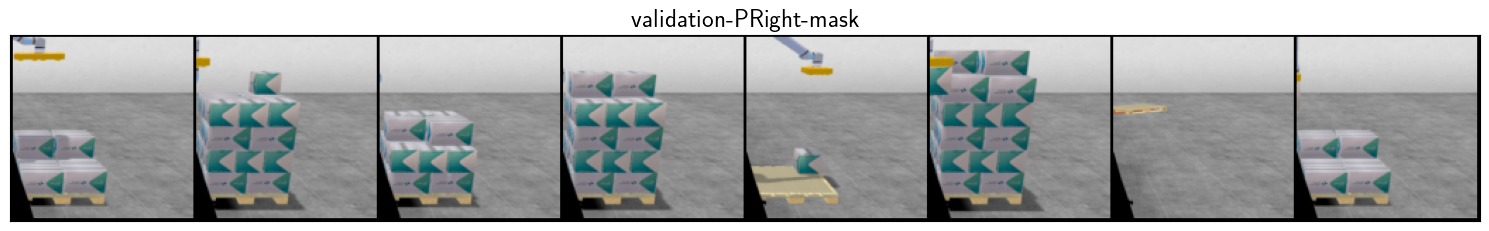

In [14]:
# %%time
import random
import torch

# random indices
random_sample = random.sample(range(len(val_dataset)), 8)
print(f"Random indices selected: {random_sample}")

# get samples
samples = [val_dataset[i] for i in random_sample]

# if dataset returns tuples like (image, label, ...)
images = [s[0] for s in samples]

# stack into a tensor batch
real_batch = torch.stack(images)

print("Batch size:", real_batch.shape[0])
print("Computed image_size:\t", real_batch[0].shape)

# visualize
utc.show_and_save(
    f"validation-{params.subgroup}-{params.subgroup_mask}",
    real_batch,
    paths,
    data_type='tensor',   # or remove if tensor is default
    img_count=min(8, len(real_batch)),
    destroy_fig=False,
    fontsize=18
)

In [15]:
mask_image_name = 3015
CHECK_SEGMENTATION = True
# CHECK_SEGMENTATION = False

In [16]:
display(df_anom_meta[(df_anom_meta.component==params.subgroup) & (df_anom_meta.component_anomaly=='ANOMALOUS')].head(5))
anom_index_5 = df_anom_meta[(df_anom_meta.component==params.subgroup) & (df_anom_meta.component_anomaly=='ANOMALOUS')].iloc[:5].frame_no.tolist()
print(anom_index_5)


,frame_no,image_anomaly,component,component_anomaly,image_fullname,se_filenmae,colors_found,colors_in_component,time_load_t,time_component_t,time_full_t,time_load_total_dt,time_component_total_dt,time_full_dt
2238,559,ANOMALOUS,PRight,ANOMALOUS,1751540171015536400_0559_10000010000000000,1751540171032598900_0559_10000010000000000,20,18,0.096217,0.030961,0.127178,0:00:00.096217,0:00:00.030961,0:00:00.127178
2246,561,ANOMALOUS,PRight,ANOMALOUS,1751540171437468600_0561_10000010000000000,1751540171427164200_0561_10000010000000000,20,18,0.104067,0.037273,0.141340,0:00:00.104067,0:00:00.037273,0:00:00.141340
2250,562,ANOMALOUS,PRight,ANOMALOUS,1751540171641909800_0562_10000010000000000,1751540171633403700_0562_10000010000000000,20,18,0.084908,0.029798,0.114705,0:00:00.084907,0:00:00.029797,0:00:00.114704
2254,563,ANOMALOUS,PRight,ANOMALOUS,1751540171840653400_0563_10000010000000000,1751540171848873300_0563_10000010000000000,20,18,0.091844,0.037467,0.129311,0:00:00.091844,0:00:00.037467,0:00:00.129311
2258,564,ANOMALOUS,PRight,ANOMALOUS,1751540172031039600_0564_10000010000000000,1751540172036679200_0564_10000010000000000,21,19,0.082602,0.038234,0.120836,0:00:00.082602,0:00:00.038234,0:00:00.120836


[559, 561, 562, 563, 564]


In [17]:
importlib.reload(utc)
disallowed_color,disallowed_color_meta = utc.get_disallowed_color_for_object(params.anomalous_type, mode='old', verbose=True)

anomalous_type : unexpected_person
disallowed_color : [239, 77, 223]
disallowed_color : #FF00FF


In [18]:
params.latent_dims = 64
params.latent_dims

64

In [19]:
importlib.reload(utc)
paths = utc.get_initial_paths(paths,params)
suffix,paths = utc.get_create_results_path(params.subgroup, params,paths,models_dir='models', save_path_type='cloud')
# paths.path_results_cloud

current path:		 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_cloud:	 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
Path exists:		 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
using suffix as --> PRight_64
Component :  PRight
------------------------------------------------------------------------------------------------------------------------
base_dir :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_models :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models
path_results :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\results/PRight_64
results_test :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\test/PRight_64
path_results_fix :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_

# ANOMALY SCORES DEFINITIONS

## Anomaly Score: Gaussian 

In [20]:
import cython
%load_ext Cython

In [21]:
%%cython
import numpy as np
cimport numpy as cnp
from libc.math cimport sqrt, INFINITY

def compute_distance_offset(cnp.ndarray[cnp.float32_t, ndim=3] imgA, 
                            cnp.ndarray[cnp.float32_t, ndim=3] imgB, 
                            int offset):
    """Compute minimum Euclidean distance in a search kernel for each pixel."""
    
    # Assertions to ensure both images have the same shape and type
    assert imgA.shape[0] == imgB.shape[0], "Error: imgA and imgB must have the same height"
    assert imgA.shape[1] == imgB.shape[1], "Error: imgA and imgB must have the same width"
    assert imgA.shape[2] == imgB.shape[2], "Error: imgA and imgB must have the same channels"
    assert imgA.dtype == np.float32 and imgB.dtype == np.float32, "Error: Images must be of type float32"
    
    cdef int H = imgA.shape[0]
    cdef int W = imgA.shape[1]
    cdef int C = imgA.shape[2]  # Assuming 3 channels (RGB)
    assert C==3, "Error: input images should have three channels"
    
    cdef cnp.ndarray[cnp.float32_t, ndim=2] distance = np.zeros((H, W), dtype=np.float32)

    cdef int i, j, ki, kj
    cdef float min_dist, dist, diff

    for i in range(H):
        for j in range(W):
            min_dist = INFINITY  # Initialize with a high value
            
            # Search in the kernel centered at (i, j) in imgB
            for ki in range(max(0, i - offset), min(H, i + offset + 1)):
                for kj in range(max(0, j - offset), min(W, j + offset + 1)):
                    dist = 0.0
                    for c in range(C):  # Compute Euclidean distance per channel
                        diff = imgA[i, j, c] - imgB[ki, kj, c]
                        dist += diff * diff
                    
                    dist = sqrt(dist)  # Take the square root to get the Euclidean distance
                    
                    if dist < min_dist:
                        min_dist = dist
            
            distance[i, j] = min_dist  # Assign the minimum distance found
    
    return distance

In [22]:
from scipy.ndimage import gaussian_filter

def anomaly_score_offset_sigma(imgA, imgB, offset, sigma=None, quant=1.0):
    """
    Computes the max anomaly score using compute_distance() with a given offset and optional Gaussian smoothing.
    
    Parameters:
        imgA (np.ndarray): First image (H, W, 3), float32.
        imgB (np.ndarray): Second image (H, W, 3), float32.
        offset (int): Kernel width for compute_distance().
        sigma (float or None): Standard deviation for Gaussian filter (if None, no filter applied).
    
    Returns:
        float: Maximum value of the processed distance matrix.
    """
    # Compute distance matrix with given offset
    dist_matrix = compute_distance_offset(imgA, imgB, offset)
    
    # Apply Gaussian filter if sigma is provided
    if sigma is not None:
        dist_matrix = gaussian_filter(dist_matrix, sigma=sigma)
    
    # Return max value of the distance matrix, together with the distance matrix
    return np.quantile(dist_matrix, quant), dist_matrix

In [23]:
def plot_gauss_anomaly_maps(imgA,imgB):
    kernel_widths = [0, 1, 2]  # X-axis (offset)
    gaussian_sigmas = [None, 1, 2, 3]  # Y-axis (Gaussian smoothing)

    distance_matrices = {k: compute_distance_offset(imgA, imgB, k) for k in kernel_widths}

    # Create figure
    fig, axes = plt.subplots(len(gaussian_sigmas), len(kernel_widths), figsize=(12, 8))

    for row, sigma in enumerate(gaussian_sigmas):
        for col, kernel_width in enumerate(kernel_widths):
            # Get the base distance matrix
            dist_matrix = distance_matrices[kernel_width]
            
            # Apply Gaussian filter if sigma is not None
            if sigma is not None:
                dist_matrix = gaussian_filter(dist_matrix, sigma=sigma)
            
            # Plot
            ax = axes[row, col]
            im = ax.imshow(dist_matrix, cmap='Reds', vmin=0, vmax=0.25)
            ax.set_xticks([])  # Remove axis labels for clarity
            ax.set_yticks([])

            quantiles = [0.99, 0.999, 0.9999, 1]
            qv = np.quantile(dist_matrix, quantiles)
            msg = [f'q({q})={v}' for q,v in zip(quantiles,qv)]
            # msg.append(f'max={np.max(dist_matrix)}')

            ax.text(10, 120, '\n'.join(msg))
            
            # Titles
            if row == 0:
                ax.set_title(f"Offset = {kernel_width}", fontsize=12)
            if col == 0:
                ax.set_ylabel(f"sig = {sigma}" if sigma is not None else "No Filter", fontsize=12)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [24]:
AS_SIGMA = 1
AS_OFFSET = 1
AS_QUANT = 1.0

In [25]:
def get_anomaly_score(data_batch,recon_batch,offset=AS_OFFSET,sigma=AS_SIGMA,quant=AS_QUANT, debug = False):
    if debug:
        print('data_batch.shape',data_batch.shape)
        print('recon_batch.shape',recon_batch.shape)
        
    assert len(data_batch.shape)==4
    assert len(recon_batch.shape)==4
    assert (data_batch.shape[0]==recon_batch.shape[0] and data_batch.shape[1]==recon_batch.shape[1] and
            data_batch.shape[2]==recon_batch.shape[2] and data_batch.shape[3]==recon_batch.shape[3])
    
    scores, diff_images = [], []
    for i in range(data_batch.shape[0]):
        data_ = data_batch[i].detach().cpu().numpy()
        recon_batch_ = recon_batch[i].detach().cpu().numpy()
        data_ =  np.moveaxis(data_, 0, 2)
        recon_batch_ = np.moveaxis(recon_batch_, 0, 2)
        anomaly_score,diff_img = anomaly_score_offset_sigma(data_, recon_batch_, offset, sigma, quant)
        scores.append(anomaly_score)
        diff_images.append(diff_img)
        torch.cuda.empty_cache()
    return np.array(scores), np.array(diff_images)

In [26]:
%%cython
import numpy as np
cimport numpy as cnp
from libc.math cimport sqrt, INFINITY

def compute_sign_distance_offset(cnp.ndarray[cnp.float32_t, ndim=3] imgA, 
                                 cnp.ndarray[cnp.float32_t, ndim=3] imgB, 
                                 int offset):
    """Compute minimum (in absolute) signed distance in a search kernel for each pixel."""
    
    # Assertions to ensure both images have the same shape and type
    assert imgA.shape[0] == imgB.shape[0], "Error: imgA and imgB must have the same height"
    assert imgA.shape[1] == imgB.shape[1], "Error: imgA and imgB must have the same width"
    assert imgA.shape[2] == imgB.shape[2], "Error: imgA and imgB must have the same channels"
    assert imgA.dtype == np.float32 and imgB.dtype == np.float32, "Error: Images must be of type float32"
    
    cdef int H = imgA.shape[0]
    cdef int W = imgA.shape[1]
    cdef int C = imgA.shape[2]  # Assuming 3 channels (RGB)
    assert C==3, "Error: input images should have three channels"

    cdef cnp.ndarray[cnp.float32_t, ndim=3] sign_distance = np.zeros((H, W, C), dtype=np.float32)

    cdef int i, j, ki, kj
    cdef float min_dist, dist, diff

    for i in range(H):
        for j in range(W):
            min_dist = INFINITY  # Initialize with a high value
            min_delta = None
            
            # Search in the kernel centered at (i, j) in imgB
            for ki in range(max(0, i - offset), min(H, i + offset + 1)):
                for kj in range(max(0, j - offset), min(W, j + offset + 1)):
                    dist = 0.0
                    for c in range(C):  # Compute Euclidean distance per channel
                        diff = imgA[i, j, c] - imgB[ki, kj, c]
                        dist += diff * diff
                    
                    if dist < min_dist:
                        min_dist = dist
                        min_delta = (ki, kj)
            
            ki, kj = min_delta
            for c in range(C):
                sign_distance[i, j, c] = imgA[i, j, c] - imgB[ki, kj, c]
    
    return sign_distance

In [27]:
####################################################################################################
def get_l1_difference(real_images,reconstructed_images,supress_output=False):
        """Computes L1 (absolute) difference between original and reconstructed images."""
        diff_map = torch.abs(real_images - reconstructed_images)  # (B, C, H, W)
        diff_score = diff_map.mean(dim=(1, 2, 3)).detach().cpu().numpy()  # (B,)
        if supress_output:
            diff_map = diff_map.cpu().numpy()
            diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            diff_map = np.mean(diff_map, axis=-1)  # Convert to grayscale
            diff_map = diff_map[0]  # Select first image in batch
        del diff_map
        return diff_score
####################################################################################################
def get_l2_difference(real_images,reconstructed_images):
        """Computes L2 (Euclidean) difference per pixel and overall score."""
        # diff_map = (real_images - reconstructed_images) ** 2  # Pixel-wise squared difference
        diff_score = torch.norm(real_images - reconstructed_images, p=2, dim=(1, 2, 3)).detach().cpu().numpy()  # (B,)
        # if supress_output:
        #     diff_map = diff_map.cpu().numpy()
        #     diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
        #     diff_map = np.mean(diff_map, axis=-1)  # Convert to grayscale
        #     diff_map = diff_map[0]  # Select first image in batch
        # del diff_map
        return diff_score
####################################################################################################
from skimage.metrics import structural_similarity as ssim
def get_ssim_dissimilarity_batch(real_images,reconstructed_images, ssim_type='ssim', ssim_params=None,
                                 win_size=None, gaussian_weights=None,sigma=None,
                                 supress_output=False):
        #########################################################################

        if ssim_params is not None:
            win_size, gaussian_weights,sigma = ssim_params['win_size'], ssim_params['gaussian_weights'],ssim_params['sigma']
        if ssim_params is not None and win_size is None and gaussian_weights is None and sigma is None:
            win_size,gaussian_weights,sigma = 3,True,1.5
        else:
             assert win_size is not None and gaussian_weights is not None and sigma is not None, "ssim_params should be provided"
                 
        use_sample_covariance = False

        batch_size = real_images.shape[0]
        maps, scores = [], []

        for i in range(batch_size):

            data_img = real_images[i].detach().cpu().numpy()
            recon_img = reconstructed_images[i].detach().cpu().numpy()

            data_img = np.moveaxis(data_img, 0, 2)  # (C, H, W) → (H, W, C)
            recon_img = np.moveaxis(recon_img, 0, 2)  

            # Normalize images to [0,1] range
            data_img = (data_img - data_img.min()) / (data_img.max() - data_img.min() + 1e-8)
            recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min() + 1e-8)

            # Compute SSIM similarity score and similarity map
            ssim_score, ssim_map = ssim(data_img, recon_img, data_range=1.0, 
                                        win_size=win_size,sigma = sigma,full=True,
                                        gaussian_weights=gaussian_weights,use_sample_covariance=use_sample_covariance
                                        )
            
            if ssim_type == 'ssim-d':
                ssim_result_map = 1 - ssim_map  
                ssim_result_score = 1 - ssim_score  # Convert SSIM score to dissimilarity
            else:
                ssim_result_map = ssim_map
                ssim_result_score = ssim_score

            maps.append(ssim_result_map)
            scores.append(ssim_result_score)
        maps = np.array(maps)
        scores = np.array(scores)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)

        # maps = np.moveaxis(maps, 3, 1)  # (B, C, H, W) → (B, H, W, C)
        # print('maps first',maps.shape)
        if supress_output:
            # diff_map = diff_map.cpu().numpy()
            # diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            maps = np.mean(maps, axis=-1)  # Convert to grayscale
            # print('maps',maps.shape)
            maps = maps[0]  # Select first image in batch
            # print('maps',maps.shape)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)
        
        return scores
######################################
def get_ssim_dissimilarity_baatch_maps(real_images,reconstructed_images, ssim_type='ssim', ssim_params=None,
                                 win_size=None, gaussian_weights=None,sigma=None,
                                 supress_output=False):
        #########################################################################

        if ssim_params is not None:
            win_size, gaussian_weights,sigma = ssim_params['win_size'], ssim_params['gaussian_weights'],ssim_params['sigma']
        elif len(params)==0:
             pass
        else:
            win_size,gaussian_weights,sigma = 3,True,1.5
            
        use_sample_covariance = False

        batch_size = real_images.shape[0]
        maps, scores = [], []

        for i in range(batch_size):

            data_img = real_images[i].detach().cpu().numpy()
            recon_img = reconstructed_images[i].detach().cpu().numpy()

            data_img = np.moveaxis(data_img, 0, 2)  # (C, H, W) → (H, W, C)
            recon_img = np.moveaxis(recon_img, 0, 2)  

            # Normalize images to [0,1] range
            data_img = (data_img - data_img.min()) / (data_img.max() - data_img.min() + 1e-8)
            recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min() + 1e-8)

            # Compute SSIM similarity score and similarity map
            ssim_score, ssim_map = ssim(data_img, recon_img, data_range=1.0, 
                                        win_size=win_size,sigma = sigma,full=True,
                                        gaussian_weights=gaussian_weights,use_sample_covariance=use_sample_covariance
                                        )
            
            if ssim_type == 'ssim-d':
                ssim_result_map = 1 - ssim_map  
                ssim_result_score = 1 - ssim_score  # Convert SSIM score to dissimilarity
            else:
                ssim_result_map = ssim_map
                ssim_result_score = ssim_score

            maps.append(ssim_result_map)
            scores.append(ssim_result_score)
        maps = np.array(maps)
        scores = np.array(scores)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)

        # maps = np.moveaxis(maps, 3, 1)  # (B, C, H, W) → (B, H, W, C)
        # print('maps first',maps.shape)
        if supress_output:
            # diff_map = diff_map.cpu().numpy()
            # diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            maps = np.mean(maps, axis=-1)  # Convert to grayscale
            # print('maps',maps.shape)
            maps = maps[0]  # Select first image in batch
            # print('maps',maps.shape)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)
        
        return maps

In [28]:
# # def get_anomaly_score_ravi(real_images, reconstructed_images, quantile=1.0):
# #     abs_diffs = torch.abs(real_images - reconstructed_images)
# #     mean_diffs = abs_diffs.mean(dim=1).cpu().detach().numpy()
# #     mean_diffs = mean_diffs.reshape(mean_diffs.shape[0], -1)
# #     scores = np.quantile(mean_diffs, q=quantile, axis=1)
# #     return scores

def get_anomaly_score_distance_offset_quant(real_images, reconstructed_images, offset=1, quantile=1.0, sigma=0):
    real_images_np = real_images.permute(0, 2, 3, 1).cpu().detach().numpy().astype(np.float32)
    reconstructed_images_np = reconstructed_images.permute(0, 2, 3, 1).cpu().detach().numpy().astype(np.float32)
    
    batch_scores = []
    for real_img, recon_img in zip(real_images_np, reconstructed_images_np):
        # sign_distances = compute_sign_distance_offset(real_img, recon_img, offset)
        sign_distances = image_reconstruction_signed_similarity_map(real_img, recon_img, offset=offset, sigma=sigma)
        max_score = np.quantile(np.abs(sign_distances), q=quantile)
        batch_scores.append(max_score)
    
    return np.array(batch_scores)


In [29]:
from utils_CAD import get_anomaly_score_ravi

In [30]:
importlib.reload(utc)
paths = utc.get_initial_paths(paths,params)

current path:		 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_cloud:	 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
Path exists:		 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop


In [31]:
# Hyperparameters
params.epochs = epochs = 1000
params.batch_size   = 8
params.latent_dims  = 64

# params.exp_type = 'E1'
# params.exp_type = 'E2'
params.exp_type = 'E3'

# params.learning_rate_enc_dec  = 0.001  # 
# params.learning_rate_dis      = 0.0001 # should be 10x smaller that enc_dec to improve convergence
kl_usuage                     = True


In [32]:
importlib.reload(utc)
suffix,paths = utc.get_create_results_path(params.subgroup,params,paths,models_dir='models')


using suffix as --> PRight_64
Component :  PRight
------------------------------------------------------------------------------------------------------------------------
base_dir :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_models :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\models
path_results :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\results/PRight_64
results_test :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\test/PRight_64
path_results_fix :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\monitor/PRight_64


In [33]:
params = utc.get_parameters_by_experiment(params, verbose=True)
_ = utc.get_header(params,paths, verbose=True)

Parameters for experiment E3 are set:
Learning rate enc_dec: 0.001
Learning rate dis: 0.0001
Beta KL: 0.0001
Beta GAN: 0.0001
Reconstruction loss function: MSE
Adversarial loss function: BCWithLogits
|  dataset   |   camera   |  subgroup  |  epochs   |   latent_dims   |   input_shape   | batch_size |   LR_enc_dec    |     LR_dis      |
----------------------------------------------------------------------------------------------------------------------------------------------------------------
|     V6     |  fronttop  |   PRight   |    1000    |       64        |    3x128x128    |     8      |      0.001      |     0.0001      |


In [34]:
importlib.reload(utc)
from utils_model_CAD import Encoder, Decoder, Discriminator

# Loss functions
reconstruction_loss_fn = nn.MSELoss()  # L2 reconstruction loss
adversarial_loss_fn = nn.BCEWithLogitsLoss()  # For GAN

Enc = Encoder(z_size=params.latent_dims).to(device)
Dec = Decoder(z_size=params.latent_dims).to(device)
Dis = Discriminator().to(device)

# Optimizers
optEncDec = optim.Adam(list(Enc.parameters()) + list(Dec.parameters()), lr=params.learning_rate_enc_dec)
optDis = optim.Adam(Dis.parameters(), lr=params.learning_rate_dis)

suffix,paths = utc.get_create_results_path(params.subgroup,params,paths,models_dir='models', save_path_type='cloud')
# loss_history = []  # List of dictionaries to accumulate loss values
loss_history = utmc.load_model(Enc, Dec, Dis, optEncDec, optDis, paths, suffix, verbose=True)
print('='*100)
print('model trained?', len(loss_history))
print('='*100)

using suffix as --> PRight_64
Component :  PRight
------------------------------------------------------------------------------------------------------------------------
base_dir :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_models :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models
path_results :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\results/PRight_64
results_test :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\test/PRight_64
path_results_fix :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\monitor/PRight_64
TRYING MODEL FROM -> e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PRight_64.pt
Loaded model from e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PRight_64.pt
Model loaded at epoch 1000
model trained? 1000


In [35]:
# importlib.reload(utc)
# utc.get_status_info(loss_history,params,paths)
# utc.plot_loss_sep(loss_history,params,paths,plot_type=3, destroy_fig=False)

In [36]:
importlib.reload(utc)
# explore_latent_space = True
explore_latent_space = False

In [37]:
if explore_latent_space:
    if  len(loss_history)>0:
        Enc.eval()
        mus = []
        logvars = []
        zs = []

        with torch.no_grad():
            for x_id,(x, _) in enumerate(tqdm(train_loader)):
                x = x.to(device)
                mu, logvar = Enc(x)
                mus.append(mu.cpu())
                logvars.append(logvar.cpu())

                std = torch.exp(0.5 * logvar)
                eps = torch.randn_like(std)
                z = mu + eps * std
                zs.append(z.cpu())
                mean = np.mean(zs, axis=0)
                # cov = np.cov(zs.T)

                if x_id ==250:
                    break

        mus = torch.cat(mus, dim=0).numpy()
        zs = torch.cat(zs).numpy()
    else:
        print('MODEL NOT TRAINED ')


In [38]:
# import matplotlib.pyplot as plt
if explore_latent_space:
    if  len(loss_history)>0:
        import seaborn as sns

        dim = 0  # choose latent dimension

        plt.figure(figsize=(6,4))
        sns.histplot(mus[:, dim], kde=True, stat="density")
        plt.title(f"Latent Dimension {dim} Distribution ({params.subgroup})")
        plt.show()
    else:
        print('MODEL NOT TRAINED ')

In [39]:
# import numpy as np
if explore_latent_space:
        if  len(loss_history)>0:
                from scipy.stats import norm

                x_vals = np.linspace(-4, 4, 400)

                plt.figure(figsize=(6,4))
                plt.hist(mus[:,0], bins=50, density=True, alpha=0.5, label="Encoded $\\mu$")

                plt.plot(x_vals, norm.pdf(x_vals, 0, 1), 
                        label="Prior N(0,1)", linewidth=2)

                plt.legend()
                plt.title(f"Learned vs Prior Distribution ({params.subgroup})")
                plt.show()
        else: print('MODEL NOT TRAINED ')

In [40]:
if explore_latent_space:
    if  len(loss_history)>0:
        plt.figure(figsize=(6,6))
        plt.scatter(mus[:,0], mus[:,1], alpha=0.4)
        plt.title(f"Latent Space Distribution mus(:2) ({params.subgroup})")
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.show()
    else: print('MODEL NOT TRAINED ')

In [41]:
# if explore_latent_space:
#     if len(loss_history) > 0:
#         # for pairs in mus[:]:
#             # print(pairs.shape)

#         n_dims = mus.shape[1]
#         pairs = [(i, j) for i in range(n_dims) for j in range(i + 1, n_dims)]
#         n_pairs = len(pairs)

#         # Determine subplot grid size
#         n_cols = math.ceil(math.sqrt(n_pairs))
#         n_rows = math.ceil(n_pairs / n_cols)

#         fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
#         axes = np.array(axes).flatten()  # Flatten in case of 2D grid

#         for idx, (i, j) in enumerate(pairs):
#             ax = axes[idx]
#             ax.scatter(mus[:, i], mus[:, j], alpha=0.4, s=10)
#             ax.set_title(f"z{i+1} vs z{j+1}", fontsize=9)
#             ax.set_xlabel(f"z{i+1}")
#             ax.set_ylabel(f"z{j+1}")

#         # Hide any unused subplots
#         for idx in range(n_pairs, len(axes)):
#             axes[idx].set_visible(False)

#         fig.suptitle(f"Latent Space – All Dimension Pairs ({params.subgroup})", fontsize=13)
#         plt.tight_layout()
#         plt.show()

#     else:
#         print('MODEL NOT TRAINED')

In [42]:
# import numpy as np
# import matplotlib.pyplot as plt
if explore_latent_space:
    if  len(loss_history)>0:
        def collect_mu_logvar(encoder, dataloader, device):
            encoder.eval()
            mus, logvars = [], []
            import torch
            with torch.no_grad():
                for xid,(x, *_) in enumerate(tqdm(dataloader)):
                    x = x.to(device)
                    mu, logvar = encoder(x)          # adapt if your encoder returns differently
                    mus.append(mu.detach().cpu())
                    logvars.append(logvar.detach().cpu())
                    
                    if xid==200:
                        break

            mus = torch.cat(mus, 0).numpy()
            logvars = torch.cat(logvars, 0).numpy()
            return mus, logvars

        def sample_z(mus, logvars, n_samples=1, seed=0):
            rng = np.random.default_rng(seed)
            std = np.exp(0.5 * logvars)
            # one sample per datapoint (or more if you want)
            eps = rng.standard_normal(size=mus.shape)
            return mus + std * eps

        def plot_dims_vs_standard_normal(arr, dims=(0,1,2,3), bins=60, title=""):
            # arr: (N, D) for either mus or zs
            x = np.linspace(-4, 4, 400)
            std_norm = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*x**2)

            k = len(dims)
            fig, axes = plt.subplots(1, k, figsize=(4*k, 3), constrained_layout=True)
            if k == 1:
                axes = [axes]

            for ax, d in zip(axes, dims):
                ax.hist(arr[:, d], bins=bins, density=True, alpha=0.6)
                ax.plot(x, std_norm, linewidth=2)
                ax.set_title(f"dim {d}")
                # ax.set_xlim(-4, 4)

            plt.suptitle(title)
            # plt.tight_layout()
            plt.subplots_adjust()

            plt.show()
    else: print('MODEL NOT TRAINED ')

In [43]:
if explore_latent_space:
    if  len(loss_history)>0:
        mus, logvars = collect_mu_logvar(Enc, train_loader, device)
        zs = sample_z(mus, logvars)
    else: print('MODEL NOT TRAINED ')

In [44]:
if explore_latent_space:
    if  len(loss_history)>0:
        plot_dims_vs_standard_normal(mus, dims=(0,1,2,3), title="$$\mu(x) - N(0,1)$$")
        plot_dims_vs_standard_normal(zs,  dims=(0,1,2,3), title="Sampled z ~ q(z|x) vs N(0,1)")
    else: print('MODEL NOT TRAINED ')

In [45]:
if explore_latent_space:
    def summarize_latent(arr, name="z"):
        m = arr.mean(axis=0)
        v = arr.var(axis=0)
        print(f"{name}: mean over dims  -> avg={m.mean():.3f}, min={m.min():.3f}, max={m.max():.3f}")
        print(f"{name}: var  over dims  -> avg={v.mean():.3f}, min={v.min():.3f}, max={v.max():.3f}")

    summarize_latent(mus, "mu")
    summarize_latent(zs, "z")

In [46]:
if explore_latent_space:
    def count_active_dims(mus, thresh=1e-2):
        v = mus.var(axis=0)
        active = (v > thresh)
        return int(active.sum()), v

    n_active, var_mu = count_active_dims(mus, thresh=1e-2)
    print("Active dims:", n_active, f"/ {params.latent_dims}")

In [47]:
importlib.reload(utc)
if explore_latent_space:
    print('Computing PCA for train set')
    z_pca_train, labels_train = utc.get_explore_latent_space_batched(loader=train_loader,Enc=Enc,device=device,
                                                                   n_components=3,method="pca"
                                                                   )
    print('Computing TSNE for train set')
    z_tsne_train, labels_train = utc.get_explore_latent_space_batched(loader=train_loader,Enc=Enc,device=device,
                                                                      n_components=3,method="tsne",
                                                                      tsne_perplexity=30,tsne_n_iter=1000)

In [48]:
importlib.reload(utc)
if explore_latent_space:
    print('Computing PCA for Val set')
    z_pca_test, labels_test = utc.get_explore_latent_space_batched(loader=val_loader,Enc=Enc,device=device,
                                                                   n_components=3,method="pca")
    print('Computing TSNE for Val set')
    z_tsne_test, labels_test = utc.get_explore_latent_space_batched(loader=val_loader,Enc=Enc,device=device,
                                                                    n_components=3,method="tsne",
                                                                    tsne_perplexity=30,tsne_n_iter=1000)

In [49]:
if explore_latent_space:
    print('INSPECTING -- TRAIN');print('-'*100)
    print('LATENT SPACE USING PCA for TRAIN --> ', z_pca_train.shape)
    print('LATENT SPACE USING TSNE for TRAIN --> ', z_tsne_train.shape)
    print('INSPECTING -- Valid'); print('-'*100)
    print('LATENT SPACE USING PCA for VAL --> ', z_pca_test.shape)
    print('LATENT SPACE USING TSNE for VAL --> ', z_tsne_test.shape)
        

In [50]:
if explore_latent_space:
    paths.test_classes = {idx: cls for cls, idx in val_loader.dataset.class_to_idx.items()}
    importlib.reload(utc)
    utc.plot_latent(latent_space=z_pca_train,
                    latent_space_test=z_pca_test, 
                    labels_train=labels_train,
                    labels_test=labels_test,
                    paths=paths, 
                    labels=['train','Val'],
                    ttl = f'{params.subgroup} - PCA')
    #=================================================
    utc.plot_latent(latent_space=z_tsne_train,
                    latent_space_test=z_tsne_test, 
                labels_train=labels_train,
                labels_test=labels_test,
                paths=paths, 
                labels=['train','Val'],
                ttl = f'{params.subgroup} - TSNE')

In [51]:
if explore_latent_space:
    importlib.reload(utc)
    utc.plot_latent_3d(latent_space_train=z_pca_train,
                      latent_space_test=z_pca_test, 
                      labels_train=labels_train,
                      labels_test=labels_test,
                      paths=paths,
                      labels=['train','Val'],
                      ttl = f'({params.subgroup}) - PCA'
                      )
    
    utc.plot_latent_3d(latent_space_train=z_tsne_train,
                      latent_space_test=z_tsne_test, 
                      labels_train=labels_train,
                      labels_test=labels_test,
                      paths=paths,
                      labels=['train','Val'],
                      ttl = f'({params.subgroup}) - TSNE'
                      )
    # del z_train_trans,z_test_trans

In [52]:
if explore_latent_space:
    ## INTERACTIVE 3d Plot
    importlib.reload(utc)
    utc.plot_latent_3d_plotly_custom(
        # latent_train=z_pca_train, latent_test=z_pca_test,
        latent_train=z_tsne_train,latent_test=z_tsne_test,
        labels_train=labels_train,labels_test=labels_test,
        labels=['train','Val'],
        class_names=paths.test_classes
    )

## Interactive Latent Space Visulization

In [53]:
# CREATE_DASHBOARD_LATENT = True
CREATE_DASHBOARD_LATENT = False


In [54]:
if CREATE_DASHBOARD_LATENT:
    paths_test = []
    labels_test_check = []

    for batch in train_loader:
        # support both batch_size=1 and >1
        img, label, filename, path, folder = batch
        # label is tensor; path/filename/folder are list-like strings (batched)
        if torch.is_tensor(label):
            labels_test_check.append(label.detach().cpu().numpy())
        else:
            labels_test_check.append(np.array(label))

        # path is a list/tuple of strings for the batch
        if isinstance(path, (list, tuple)):
            paths_test.extend(list(path))
        else:
            # sometimes DataLoader gives a tuple of strings
            paths_test.extend([p for p in path])

    labels_test_check = np.concatenate(labels_test_check, axis=0)

    paths_train = []
    for batch in train_loader:
        img, label, filename, path, folder = batch
        paths_train.extend(list(path))

    assert len(paths_train) == len(z_train_trans) == len(labels_train)

In [55]:
if CREATE_DASHBOARD_LATENT:
    print(train_loader.dataset.classes)
    print(test_loader.dataset.classes)

In [56]:
if CREATE_DASHBOARD_LATENT:
    paths_test = []
    for img, label, filename, path, folder in test_loader:
        paths_test.extend(list(path))

    assert len(paths_test) == len(z_test_trans) == len(labels_test)

In [57]:
if CREATE_DASHBOARD_LATENT:
    importlib.reload(utc)
    utc.export_latent_dashboard_hover_server_v3_new(
        latent_train=z_train_trans,
        labels_train=labels_train,
        paths_train=paths_train,
        latent_test=z_test_trans,
        labels_test=labels_test,
        paths_test=paths_test,
        class_names_train=paths.train_classes,
        class_names_test=paths.test_classes,
        marker_szs = {'train':4, 'test':5},
        normal_class_name_train="good",  # <-- set to your TRAIN normal folder name
        normal_class_name_test="good",     # <-- set to your TEST normal folder name
        out_html=f"results/{DS_name}_latent_dashboard_hover.html",
        base_url=base_url,

    )

In [58]:
# import anomaly_scores as anomaly_scores

data_test = torch.ones((8,3,128,128), dtype=None).to(device)
# reconstructed_images = utmc.get_reconstructed(Enc,Dec,real_images)
recon_test = utmc.get_reconstructed(Enc,Dec,data_test)
anomaly_score,_ = get_anomaly_score(data_test,recon_test)
anomaly_score_ravi = get_anomaly_score_ravi(data_test,recon_test)

print('anomaly_score new ', anomaly_score)
print('anomaly_score_ravi ', anomaly_score_ravi)

del data_test,recon_test,anomaly_score,anomaly_score_ravi

anomaly_score new  [2.42511868 2.42000079 2.419415   2.42275214 2.41688013 2.4123919
 2.4190731  2.42146921]
anomaly_score_ravi  [1.99961317 1.99896848 1.99930799 1.99957824 1.99972057 1.9995358
 1.99981058 1.99942911]


In [59]:
from scipy.ndimage import gaussian_filter

def image_reconstruction_signed_similarity_map(imgA, imgB, offset=1, sigma=0):
    sng_dist_mat = compute_sign_distance_offset(imgA, imgB, offset)
    if sigma > 0:
        # sng_dist_mat = gaussian_filter(sng_dist_mat, sigma=sigma)
        sng_dist_mat[:,:,0] = gaussian_filter(sng_dist_mat[:,:,0], sigma=sigma)
        sng_dist_mat[:,:,1] = gaussian_filter(sng_dist_mat[:,:,1], sigma=sigma)
        sng_dist_mat[:,:,2] = gaussian_filter(sng_dist_mat[:,:,2], sigma=sigma)
    # sng_dist_mat = np.mean(np.abs(sng_dist_mat), axis=2)
    sng_dist_mat = np.sqrt(np.sum(np.square(sng_dist_mat), axis=2)) # Euclidean distance
    return sng_dist_mat

def image_reconstruction_similarity_map(imgA, imgB, offset=1, sigma=0):
    dist_mat = compute_distance_offset(imgA, imgB, offset)
    if sigma > 0:
        dist_mat = gaussian_filter(dist_mat, sigma=sigma)
    return dist_mat

## ANOM SCORES

In [60]:
simple_test = False
# simple_test = True


anomaly_scores_fn = [
    ('Ravi',                get_anomaly_score_ravi,               image_reconstruction_similarity_map),
    ('Ravi-Q', lambda i,r : get_anomaly_score_ravi(i,r, 0.99999), image_reconstruction_similarity_map),
    ('L1',                  get_l1_difference                   , image_reconstruction_similarity_map), # L1 absolute difference
    ('L2',                  get_l2_difference                   , image_reconstruction_similarity_map), # L2 Euclidean difference per pixel and overall score
    ('SSIMd',  lambda i,r : get_ssim_dissimilarity_batch(i,r,ssim_type='ssim-d', ssim_params = opt),image_reconstruction_similarity_map), 
    # Computes SSIM-based dissimilarity maps (1 - SSIM)
    
    # ('S1diff', get_anomaly_score_distance_offset_quant),
    # ('S1diff-Q', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 1, 0.99999)),
    # ('S2diff', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2)),
    # ('S3diff', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 3)),
    # ('S2diff-Q', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, 0.99999)),
    # ('S2diff-G', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=1)),
    # ('S2diff-g', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=0.5)),
    # ('S2diff-QG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=0.99999, sigma=1)),
    # ('S2diff-GG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=1.5)),
    # ('S2diff-QGG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=0.99999, sigma=1.5)),
]
###################################################################################################
## SIMPLE OFFSET DISTANCE

###################################################################################################
if simple_test:
    win_size_ls             = [1]
    sigma_ls                = [1.0]
    gaussian_weights_ls     = [False, True]
    aggregation_function_ls = ['max', 'q-99', 'q-999']
else:
    win_size_ls             = [1, 3]
    sigma_ls                = [1.0, 1.5, 2.0]
    gaussian_weights_ls     = [False, True]
    aggregation_function_ls = ['max', 'q-99', 'q-999']

###################################################################################################
for win_size in win_size_ls:
    for gaussian_weights in gaussian_weights_ls:
        for sigma in sigma_ls:
            anomaly_scores_fn.append((f'SSIM-w{win_size}-g{gaussian_weights}-s{sigma}', 
                                lambda i,r, win_size=win_size, gaussian_weights=gaussian_weights, sigma=sigma: 
                                    get_ssim_dissimilarity_batch(i,r,ssim_type='ssim-d',
                                                                 win_size=win_size,
                                                                 gaussian_weights=gaussian_weights,
                                                                 sigma=sigma),
                                lambda i,r, win_size=win_size, gaussian_weights=gaussian_weights, sigma=sigma: 
                                    get_ssim_dissimilarity_batch_maps(i, r,ssim_type='ssim-d',
                                                                      win_size=win_size,
                                                                      gaussian_weights=gaussian_weights,
                                                                      sigma=sigma)))
###################################################################################################
if simple_test:
    offset_ls = [1]
    quantile_ls = [1.0]
    sigma_ls = [0.5, 1.0, 1.5]
else:
    offset_ls = [1,2,3]
    # quantile_ls = [1.0, 0.999, 0.99, 0.98, 0.95]
    quantile_ls = [1.0, 0.999, 0.99]
    sigma_ls = [0, 0.5, 1.0, 1.5]

###################################################################################################

for offset in offset_ls:
    for quantile in quantile_ls:
        for sigma in sigma_ls:
            anomaly_scores_fn.append((f'OFF-o{offset}-q{quantile}-s{sigma}', 
                                   lambda i,r, offset=offset, quantile=quantile, sigma=sigma: 
                                        get_anomaly_score_distance_offset_quant(i,r, offset=offset, quantile=quantile, sigma=sigma),
                                   lambda i,r, offset=offset, sigma=sigma: 
                                        image_reconstruction_signed_similarity_map(i, r, offset=offset, sigma=sigma)))
###################################################################################################
print ('total anomaly_scores --> ', len(anomaly_scores_fn))

# for name,_,_ in anomaly_scores_fn:
#     print(name)

total anomaly_scores -->  53


In [61]:
# anomaly_scores_fn

In [62]:
other_methods = []
ssim_methods = []
OFFSET_methods = []

for name,_,_ in anomaly_scores_fn:
    # print('-'*100)
    if name.startswith('SSIM'):
        # print('SSIM')
        ssim_methods.append(name)
    elif name.startswith('OFF'):
        # print('OFF')
        OFFSET_methods.append(name)
    else:
        other_methods.append(name)


print('ssim_methods : ', len(ssim_methods))
print('OFFSET_methods : ', len(OFFSET_methods))
print('other_methods : ', len(other_methods), other_methods)

print()


ssim_methods :  13
OFFSET_methods :  36
other_methods :  4 ['Ravi', 'Ravi-Q', 'L1', 'L2']



In [63]:
AS_OFFSET, AS_QUANT, AS_SIGMA

(1, 1.0, 1)

In [64]:
def get_index_used_for_calibration(offset=3,sigma=1.0,quan=0.99):

    for ind,(as_name, as_mm, as_mmm) in enumerate(anomaly_scores_fn):
        if as_name.startswith('OFF'):
            as_name_o = as_name.split('-')
            if as_name_o[1]==f'o{offset}' and as_name_o[2]==f'q{quan}' and as_name_o[-1]==f's{sigma}':
                # print('FOUND ')
            
                # print(ind, as_name, as_mm, as_mmm)
                return ind, as_name, as_mm, as_mmm
        # print(ind, as_name, as_name_o,'\t', (as_name_o[1]=='o1' and as_name_o[2]=='q1.0'), as_name_o[1])
    

In [65]:
get_index_used_for_calibration()

(51,
 'OFF-o3-q0.99-s1.0',
 <function __main__.<lambda>(i, r, offset=3, quantile=0.99, sigma=1.0)>,
 <function __main__.<lambda>(i, r, offset=3, sigma=1.0)>)

In [66]:
# def load_tuned_threshold(paths, params,component=None, VERBOSE=False):
#     if component is None:
#         return None, None, None, None
    
#     save_dir = f'{paths.path_codes_main}/test/threshold/plots_anomaly_results-{component}'
#     csv_path = os.path.join(save_dir, "anomaly_metrics.csv")
#     if os.path.exists(csv_path):
#         # os.remove(csv_path)
#         df = pd.read_csv(csv_path, index_col=0)
#         df['original_index'] = df.index
#         df['original_position'] = range(len(df))

#         sorted_df = df.sort_values(by='binormal_AUC', ascending=False)
#         if VERBOSE:
#             print('subgroup :', component)
#         # df.head()
#         best_anom_score, \
#             best_anomaly_score_index,\
#                 best_threshold = sorted_df.iloc[0].name, sorted_df.iloc[0].original_position,sorted_df.iloc[0].Threshold

#         return best_anom_score, best_anomaly_score_index, best_threshold, sorted_df
#     else:
#         raise FileNotFoundError(f"CSV file not found at {csv_path}")

TRYING TO LOAD FOR  PRight
using suffix as --> PRight_64


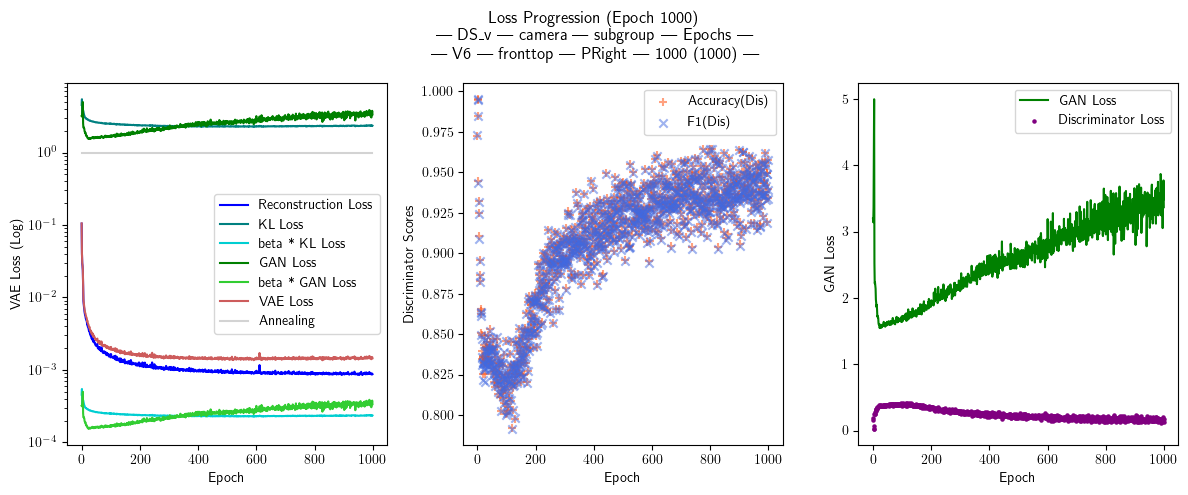

In [67]:
import copy

components_ls = [params.subgroup]


# components_ls = ['PLeft','RoboArm','PRight','ConvBelt']#, 'bg']

# components_ls = ['PRight']
# components_ls = ['PLeft']

models_dict = {}

for component in components_ls:
    # params.subgroup = component
    params.subgroup_mask = 'mask'
    print('TRYING TO LOAD FOR ', component)
    params.aug_type = f'auto-{params.subgroup_mask}'
    suffix, paths = utc.get_create_results_path(component, params, paths, save_path_type='cloud', verbose=False)
    
    # Deep copy the model structures
    enc = copy.deepcopy(Enc)
    dec = copy.deepcopy(Dec)
    dis = copy.deepcopy(Dis)
    
    # Initialize optimizers
    optEncDec, optDis = utmc.get_optimizers(Enc, Dec, Dis, verbose=False)

    # Load models
    loss_history = utmc.load_model(enc, dec, dis, optEncDec, optDis, paths, suffix, verbose=False)
    
    # Store in dictionary
    models_dict[component] = {
        'encoder': enc,
        'decoder': dec,
        'discriminator': dis,
        'optEncDec': optEncDec,
        'optDis': optDis,
        'path': os.path.join(paths.path_models, f"model_{suffix}.pt")
    }
    utc.plot_loss_sep(loss_history, params, paths, destroy_fig=False)

In [68]:
print(anom_index_5[3], anom_index_5[4])

563 564


In [69]:
paths.threshold_results = os.path.join(os.path.join(paths.path_codes, paths.dataset_type), 'threshold_results')
os.makedirs(paths.threshold_results, exist_ok=True)
csv_filename_anomaly_scores_train = f'{paths.threshold_results}/train_{paths.dataset_type}_{suffix}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'

In [70]:
# csv_filename_anomaly_scores_train = f'{paths.threshold_results}/train_{paths.dataset_type}_{suffix}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'
print('csv_filename_anomaly_scores_train', csv_filename_anomaly_scores_train)

csv_filename_anomaly_scores_train e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/train_fronttop_PRight_64_anomaly_scores_1_1_1.0.csv


In [71]:
# params.subgroup = components
params.subgroup, subgroup, component, suffix


('PRight', 'PRight', 'PRight', 'PRight_64')

In [72]:
# GENERATE_DATASET_FOR_PHVAE = False
GENERATE_DATASET_FOR_PHVAE = True

if GENERATE_DATASET_FOR_PHVAE:
    quantile_ls_mpt=[1,0.99,0.98,0.97,0.96,0.95,0.90,0.80,0.50]


In [73]:
def get_multi_point_scores_mini(
    input_images,
    reconstructed_images,
    *,
    # label=None,
    # label_name=None,
    # img_name=None,
    quantile_ls_mpt=(1, 0.99, 0.98, 0.97, 0.96, 0.95, 0.90, 0.80, 0.50),
    sigma_ls=(0,1, 2, 3),
    offset_ls=(0,),
    debug=False
):
    # input_images_np = input_images.permute(0, 2, 3, 1).detach().cpu().numpy().astype(np.float32)[0]
    # reconstructed_images_np = reconstructed_images.permute(0, 2, 3, 1).detach().cpu().numpy().astype(np.float32)[0]

    results = []

    for offset in offset_ls:
        diff = compute_distance_offset(input_images, reconstructed_images, offset=offset)

        for sigma in sigma_ls:
            blurred = gaussian_filter(diff, sigma=sigma)
            quant_values = np.quantile(blurred, q=quantile_ls_mpt)

            # Build wide dict
            row_dict = {
                # "img_no": img_name,
                # "label": int(label) if label is not None else None,
                # "label_name": label_name,
                "offset": offset,
                "sigma": sigma,
            }

            # Add quantiles as separate columns
            for q, val in zip(quantile_ls_mpt, quant_values):
                col_name = f"q_{q:.2f}".replace(".", "_")
                row_dict[col_name] = float(val)

            results.append(row_dict)

    return results

In [74]:
train_loader, val_loader, train_dataset, val_dataset, split_info = \
    get_data_loaders_from_preprocessed_with_saved_split(
        train_dir_processed_subgroup=paths.train_dir_processed_subgroup,
        split_save_path=split_save_path,
        augmentation_type='custom',
        run_mode='testing',
        batch_size_train = params.batch_size,
        batch_size_val = params.batch_size,
        shuffle_train=False,
        shuffle_val=False,
        drop_last_train=True,
        drop_last_val=False,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        verbose=True
    )

paths.train_classes = {idx: cls for cls, idx in train_dataset.class_to_idx.items()}
paths.class_names_train = train_dataset.classes

print('-' * 120)
print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))

print("Example train file:", train_dataset.imgs[0])
print("Example val file  :", val_dataset.imgs[0])

---- DATA LOADER with saved split + custom augmentation ----
train_dataset: 4807
val_dataset  : 1201
split file   : D:/DS/VeleriaLab\V6\fronttop\train_processed\PRight\split_4train_1val_PRight.json
------------------------------------------------------------------------------------------------------------------------
Train samples: 4807
Val samples  : 1201
Example train file: ('D:/DS/VeleriaLab\\V6\\fronttop\\train_processed\\PRight\\normal\\fronttop_0000_unknown.png', 0)
Example val file  : ('D:/DS/VeleriaLab\\V6\\fronttop\\train_processed\\PRight\\normal\\fronttop_0004_unknown.png', 0)


In [75]:
orig_img = train_dataset[0][0]  # (C, H, W)
print("Original image shape (C, H, W):", orig_img.shape)


Original image shape (C, H, W): torch.Size([3, 128, 128])


In [76]:
if GENERATE_DATASET_FOR_PHVAE:
        data_to_csv = []
        data_to_csv_component = []
        paths.threshold_results = os.path.join(os.path.join(paths.path_codes, paths.dataset_type), 'threshold_results')
        os.makedirs(paths.threshold_results, exist_ok=True)
        print('paths.threshold_results', paths.threshold_results)
        csv_filename_anomaly_scores_multi = f'{paths.threshold_results}/Synthetic_{paths.dataset_type}_{params.subgroup}_anomaly_scores_multipoint.csv'
        print('csv_filename_anomaly_scores_multi', csv_filename_anomaly_scores_multi)

        for idx,(data_test,lbls_test) in enumerate(tqdm(val_loader, desc='Running Full set')):
                # if idx!=1066: continue

                # test_img,img_fname,img_lbl = val_dataset[0], val_dataset.imgs[0][0], val_dataset.imgs[0][1]
                test_img,img_fname,img_lbl = val_dataset[idx], val_dataset.imgs[idx][0], val_dataset.imgs[idx][1]
                img_fname_final = f'fronttop_'+str(img_fname.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1])
                
                real_batch = np.transpose(data_test[0].numpy() * 0.5 + 0.5, (1, 2, 0))
                time_recons_start = utc.get_time(suff='start', verbose=False)
                
                data_test = data_test.to(device, non_blocking=True)
                # plt.imshow(real_batch)

                recon_test = utmc.get_reconstructed(Enc, Dec, data_test)
                orig_img = np.transpose(data_test[0].detach().cpu().numpy() * 0.5 + 0.5, (1, 2, 0))
                recon_img = np.transpose(recon_test[0].detach().cpu().numpy() * 0.5 + 0.5, (1, 2, 0))

                if idx==0:
                        print(f"TIME Reconst \t {format(utc.get_time(suff='start', verbose=False) - time_recons_start)}")
                anomaly_score,_ = get_anomaly_score(data_test,recon_test, AS_OFFSET, AS_SIGMA, AS_QUANT)

                anomaly_score_f  = np.expand_dims(anomaly_score, axis = 0)

                quant_dicts = get_multi_point_scores_mini(
                        orig_img,
                        recon_img,
                        offset_ls=offset_ls,
                        sigma_ls=[0,1, 2, 3],
                        quantile_ls_mpt=quantile_ls_mpt,
                        )
                data = {}

                for qd in quant_dicts:
                        # print(qd)
                        qd_qs = [val for key, val in qd.items() if key.startswith('q')]
                        data = {'frame': img_fname_final.split('_')[-1],
                                        'component':params.subgroup,
                                        'offset' : qd['offset'],
                                        'sigma': qd['sigma'],
                                        }
                        for q, val in zip(quantile_ls_mpt, qd_qs):
                                # print(q,val)
                                col_name = f"q_{q:.2f}".replace(".", "_")
                                data[col_name] = val

                        data_to_csv_component.append(data)
                # data_to_csv.append(data)
                torch.cuda.empty_cache()
                df_val_multi = pd.DataFrame(data_to_csv_component)
                df_val_multi.to_csv(csv_filename_anomaly_scores_multi)

                # break
        
        df_val_multi.to_csv(csv_filename_anomaly_scores_multi)

paths.threshold_results e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results
csv_filename_anomaly_scores_multi e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/Synthetic_fronttop_PRight_anomaly_scores_multipoint.csv


Running Full set:   0%|          | 0/151 [00:00<?, ?it/s]

TIME Reconst 	 0:00:00.063472


In [80]:
len(val_dataset)

1201

In [78]:
if GENERATE_DATASET_FOR_PHVAE:
    df_val_multi.to_csv(csv_filename_anomaly_scores_multi, index=False)

In [79]:
df_val_multi

,frame,component,offset,sigma,q_1_00,q_0_99,q_0_98,q_0_97,q_0_96,q_0_95,q_0_90,q_0_80,q_0_50
0,0004,PRight,1,0,0.111622,0.033515,0.022419,0.017013,0.014908,0.013305,0.009995,0.007564,0.004457
1,0004,PRight,1,1,0.048927,0.027380,0.022240,0.018036,0.014755,0.012346,0.008152,0.006574,0.004956
2,0004,PRight,1,2,0.030915,0.023157,0.019998,0.016965,0.014679,0.012662,0.008140,0.006348,0.005158
3,0004,PRight,1,3,0.024319,0.019839,0.017960,0.015851,0.014091,0.012719,0.008693,0.006296,0.005255
4,0004,PRight,2,0,0.104918,0.029359,0.018574,0.014357,0.011821,0.010518,0.007807,0.005592,0.003411
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807,0754,PRight,2,3,0.046184,0.020702,0.018726,0.017544,0.016510,0.015529,0.012860,0.006983,0.004469
1808,0754,PRight,3,0,0.205248,0.035214,0.025001,0.019907,0.016889,0.014902,0.009674,0.006013,0.003228
1809,0754,PRight,3,1,0.096820,0.026901,0.021277,0.018154,0.016498,0.015028,0.009836,0.005587,0.003471
1810,0754,PRight,3,2,0.061805,0.021522,0.018255,0.016480,0.015217,0.014369,0.010777,0.005605,0.003562


In [77]:
if GENERATE_DATASET_FOR_PHVAE:
    display(df_val_multi.head(2))

In [80]:
ind,nam,*_ = get_index_used_for_calibration()
print(nam)

splitted_as = nam.split('-')
if splitted_as[0]=='OFF':
    print(splitted_as)
    AS_OFFSET = int(splitted_as[1].split('o')[-1])
    AS_QUANT = float(splitted_as[2].split('q')[-1])
    AS_SIGMA = float(splitted_as[3].split('s')[-1])

print(AS_OFFSET, AS_QUANT, AS_SIGMA, type(AS_OFFSET))
    # print(splitted_as[1])
# selected_best_ASF = 


OFF-o3-q0.99-s1.0
['OFF', 'o3', 'q0.99', 's1.0']
3 0.99 1.0 <class 'int'>


In [81]:
def print_header(str = '-'):
    print(str*100)

In [82]:
def get_threshold(df_, selector='max', quantile=0.99):
    scores = df_.anomaly_score

    if selector == 'max':
        return scores.max()

    elif selector == 'q':
        return scores.quantile(quantile)   # 0.99 → top 1%, 0.95 → top 5%

    else:
        raise ValueError(f"Unknown selector '{selector}'. Choose from: max, quantile")

## COMPUTE/LOAD FOR TRAIN SET

In [90]:
# COMPUTE_TAU_FROM_TRAIN_SET = True
COMPUTE_TAU_FROM_TRAIN_SET = False


In [91]:
paths.threshold_results = os.path.join(paths.path_codes, paths.dataset_type, 'threshold_results')
os.makedirs(paths.threshold_results, exist_ok=True)

print('paths.threshold_results', paths.threshold_results)

csv_filename_anomaly_scores_train = (f'{paths.threshold_results}/train_{paths.dataset_type}_{params.subgroup}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv')

print('csv_filename_anomaly_scores_train', csv_filename_anomaly_scores_train)

paths.threshold_results e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results
csv_filename_anomaly_scores_train e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/train_fronttop_RoboArm_anomaly_scores_3_1.0_0.99.csv


In [92]:
if COMPUTE_TAU_FROM_TRAIN_SET:
    data_to_csv = []

    global_idx = 0

    for idx, (data_train, lbls_test) in enumerate(tqdm(train_loader, desc='Running Full set')):

        batch_size = data_train.shape[0]

        data_train = data_train.to(device, non_blocking=True)

        # reconstruction
        time_recons_start = utc.get_time(suff='start', verbose=False)
        recon_train = utmc.get_reconstructed(Enc, Dec, data_train)

        if idx == 0:
            print(f"TIME Reconst \t {format(utc.get_time(suff='start', verbose=False) - time_recons_start)}")

        # anomaly score for the whole batch
        # anomaly_scores, _ = get_anomaly_score(data_train, recon_test, AS_OFFSET, AS_SIGMA, AS_QUANT)
        anomaly_scores, _ = get_anomaly_score(data_train, recon_train, AS_OFFSET, AS_SIGMA, AS_QUANT)


        # anomaly_scores = anomaly_scores.detach().cpu().numpy()

        for b in range(batch_size):

            img_fname = train_dataset.imgs[global_idx][0]
            img_lbl = train_dataset.imgs[global_idx][1]

            img_fname_final = f'fronttop_' + str(
                img_fname.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1]
            )

            data = {
                'file_name': img_fname_final,
                'anomaly_score': f"{anomaly_scores[b]:0.6f}",
                'label': img_lbl
            }

            data_to_csv.append(data)

            global_idx += 1
        
        torch.cuda.empty_cache()

    df_train = pd.DataFrame(data_to_csv)

    df_train.to_csv(csv_filename_anomaly_scores_train, index=False)
else:
    if os.path.exists(csv_filename_anomaly_scores_train):
        df_train = pd.read_csv(csv_filename_anomaly_scores_train)
    else:
        print(f'FILE DOESNT EXIST {csv_filename_anomaly_scores_train}')

In [93]:
print(f' Scores for {params.subgroup} using Train data')
df_train.sort_values('anomaly_score', ascending=False).head(3)

 Scores for RoboArm using Train data


,file_name,anomaly_score,label
2605,fronttop_3256,0.411752,0
4620,fronttop_5775,0.214997,0
4764,fronttop_5955,0.191118,0


In [94]:
df_train

,file_name,anomaly_score,label
0,fronttop_0000,0.069866,0
1,fronttop_0001,0.070982,0
2,fronttop_0002,0.069543,0
3,fronttop_0003,0.070495,0
4,fronttop_0005,0.070411,0
...,...,...,...
4795,fronttop_5993,0.045755,0
4796,fronttop_5995,0.045267,0
4797,fronttop_5996,0.051604,0
4798,fronttop_5997,0.040937,0


In [89]:
df_train

,file_name,anomaly_score,label
0,fronttop_0000,0.069866,0
1,fronttop_0001,0.070982,0
2,fronttop_0002,0.069543,0
3,fronttop_0003,0.070495,0
4,fronttop_0005,0.070411,0
...,...,...,...
4795,fronttop_5993,0.045755,0
4796,fronttop_5995,0.045267,0
4797,fronttop_5996,0.051604,0
4798,fronttop_5997,0.040937,0


In [95]:
print('---          Train          ---')
print('-'*100)
print(f"top 0%\t: {get_threshold(df_train, selector='q', quantile=1.00):0.3}")
print(f"top 1%\t: {get_threshold(df_train, selector='q', quantile=0.99):0.3}")   # top 1%
print(f"top 5%\t: {get_threshold(df_train, selector='q', quantile=0.95):0.3}")   # top 5%
print(f"top 10%\t: {get_threshold(df_train, selector='q', quantile=0.90):0.3}")   # top 10%
print('-'*100)

---          Train          ---
----------------------------------------------------------------------------------------------------
top 0%	: 0.412
top 1%	: 0.16
top 5%	: 0.0936
top 10%	: 0.0872
----------------------------------------------------------------------------------------------------


In [96]:
importlib.reload(utc)

<module 'utils_CAD' from 'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\utils_CAD.py'>

In [97]:
def verify_max_values(dataset,index=0, data_type='train', imgs=None, show_colorbar = True):
    if imgs is None:
        test_img,img_fname,img_lbl = dataset[index], dataset.imgs[index][0], dataset.imgs[index][1]
        img_fname_final = f'fronttop_'+str(img_fname.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1])

        index = int(index)
        image_tensor, _ = dataset[index]
        image_fname = dataset.samples[index][0].split('\\')[-1].split('.')[0]
    #########################################
        image_full,_ = dataset[index]
        image_full = np.transpose(image_full.numpy() * 0.5 + 0.5, (1, 2, 0))
    #########################################
        print(f'FILE: ', index,image_fname )
        data_test = dataset[index][0].unsqueeze(dim=0).to(device)
    else:
        _,img_fname,_ = dataset[index], dataset.imgs[index][0], dataset.imgs[index][1]
        img_fname_final = f'fronttop_'+str(img_fname.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1])

        data_test = imgs.unsqueeze(dim=0)
        
    recon_test = utmc.get_reconstructed(Enc, Dec, data_test).to(device)

    anomaly_score,_ = get_anomaly_score(data_test,recon_test, AS_OFFSET, AS_SIGMA, AS_QUANT)
    print(anomaly_score)
    utc.plot_test_single(data_test,
                        recon_test, 
                        len(loss_history),
                        ttl = img_fname_final,
                        data_type = data_type,
                        save_path=paths.results_test,
                        plot_anomaly_scores=True,
                        anomaly_score=anomaly_score[0],
                        plot_suptitle = False,   ##############
                        save_fig=True,
                        show_colorbar=show_colorbar,
                        destroy_fig=False, fontsize=14)

In [98]:
# df_train.loc[df_train.anomaly_score.idxmax()]

In [99]:
top_1_fname,top_1_as = df_train.loc[df_train.anomaly_score.idxmax()].file_name, df_train.loc[df_train.anomaly_score.idxmax()].anomaly_score
# 
top_1_fname.split('_')[-1], top_1_as




('3256', 0.411752)

target_idx: 2605
FILE:  2605 fronttop_3256_unknown
[0.40542769]



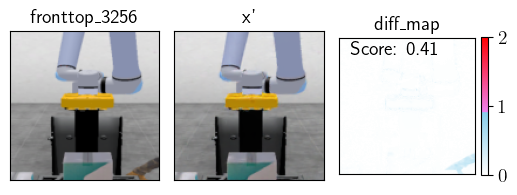

In [100]:
top_1_fname = top_1_fname.strip()   # e.g. 'fronttop_1196'

target_idx = None
for i, (img_path, img_lbl) in enumerate(train_dataset.imgs):
    fname = 'fronttop_' + img_path.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1]
    if fname == top_1_fname:
        target_idx = i
        break

print("target_idx:", target_idx)

verify_max_values(train_dataset,index=target_idx)

## VALIDATION SET

In [101]:
#-------------------------------------------------------------------------------------------
COMPUTE_TAU_FROM_VALID_SET = True
# COMPUTE_TAU_FROM_VALID_SET = False
#-------------------------------------------------------------------------------------------
paths.threshold_results = os.path.join(paths.path_codes, paths.dataset_type, 'threshold_results')
os.makedirs(paths.threshold_results, exist_ok=True)

print('paths.threshold_results', paths.threshold_results)

csv_filename_anomaly_scores_val = (
    f'{paths.threshold_results}/val_{paths.dataset_type}_{params.subgroup}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'
)

print('csv_filename_anomaly_scores_val', csv_filename_anomaly_scores_val)


paths.threshold_results e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results
csv_filename_anomaly_scores_val e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/val_fronttop_RoboArm_anomaly_scores_3_1.0_0.99.csv


In [102]:
if COMPUTE_TAU_FROM_VALID_SET:
    data_to_csv = []

    global_idx = 0

    for idx, (data_val, lbls_val) in enumerate(tqdm(val_loader, desc='Running Full set')):

        batch_size = data_val.shape[0]
        data_val = data_val.to(device, non_blocking=True)

        time_recons_start = utc.get_time(suff='start', verbose=False)
        recon_test = utmc.get_reconstructed(Enc, Dec, data_val)

        if idx == 0:
            print(f"TIME Reconst \t {format(utc.get_time(suff='start', verbose=False) - time_recons_start)}")

        anomaly_scores, _ = get_anomaly_score(data_val, recon_test, AS_OFFSET, AS_SIGMA, AS_QUANT)

        if torch.is_tensor(anomaly_scores):
            anomaly_scores = anomaly_scores.detach().cpu().numpy()

        for b in range(batch_size):
            img_fname = val_dataset.imgs[global_idx][0]
            img_lbl = val_dataset.imgs[global_idx][1]

            img_fname_final = 'fronttop_' + str(
                img_fname.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1]
            )

            data = {
                'file_name': img_fname_final,
                'anomaly_score': float(anomaly_scores[b]),
                'label': img_lbl
            }

            data_to_csv.append(data)
            global_idx += 1

        torch.cuda.empty_cache()

    df_val = pd.DataFrame(data_to_csv)
    df_val.to_csv(csv_filename_anomaly_scores_val, index=False)

    display(df_val.head(2))
    display(df_val.loc[[df_val.anomaly_score.idxmax()]])
else:
    if os.path.exists(csv_filename_anomaly_scores_val):
        df_val = pd.read_csv(csv_filename_anomaly_scores_val)
        display(df_val.head(2))
    else:
        print(f'FILE DOESNT EXIST {csv_filename_anomaly_scores_val}')

Running Full set:   0%|          | 0/151 [00:00<?, ?it/s]

TIME Reconst 	 0:00:00.021014


,file_name,anomaly_score,label
0,fronttop_0004,0.071513,0
1,fronttop_0009,0.070617,0


,file_name,anomaly_score,label
605,fronttop_3029,1.111726,0


In [106]:
if os.path.exists(csv_filename_anomaly_scores_val):
    df_val = pd.read_csv(csv_filename_anomaly_scores_val)
    display(df_val.head(2))
    

,file_name,anomaly_score,label
0,fronttop_0004,0.071513,0
1,fronttop_0009,0.070617,0


In [107]:
print('---          VALIDATION          ---')
print('-'*50)
print(f"top 0%\t: {get_threshold(df_val, selector='q', quantile=1.00):0.3}")
print(f"top 1%\t: {get_threshold(df_val, selector='q', quantile=0.99):0.3}")   # top 1%
print(f"top 5%\t: {get_threshold(df_val, selector='q', quantile=0.95):0.3}")   # top 5%
print(f"top 10%\t: {get_threshold(df_val, selector='q', quantile=0.90):0.3}")   # top 10%
print('-'*50)


---          VALIDATION          ---
--------------------------------------------------
top 0%	: 1.11
top 1%	: 0.394
top 5%	: 0.133
top 10%	: 0.0977
--------------------------------------------------


In [111]:
print_header()
print(f' Scores for | {params.subgroup} |,  using  Val data')
print_header()
df_val.sort_values('anomaly_score', ascending=False).head(3)

----------------------------------------------------------------------------------------------------
 Scores for | RoboArm |,  using  Val data
----------------------------------------------------------------------------------------------------


,file_name,anomaly_score,label
605,fronttop_3029,1.111726,0
606,fronttop_3034,0.678076,0
653,fronttop_3269,0.644358,0


In [112]:
# display(df_val)

df_val.loc[[df_val.anomaly_score.idxmax()]]

,file_name,anomaly_score,label
605,fronttop_3029,1.111726,0


In [113]:
top_1_fname,top_1_as = df_val.loc[df_val.anomaly_score.idxmax()].file_name, df_val.loc[df_val.anomaly_score.idxmax()].anomaly_score

top_1_fname.split('_')[-1], top_1_as

('3029', 1.1117264032363894)

In [114]:
index = int(top_1_fname.split('_')[-1])

dataset = val_dataset

target_idx: 605
FILE:  605 fronttop_3029_unknown
[1.11965467]



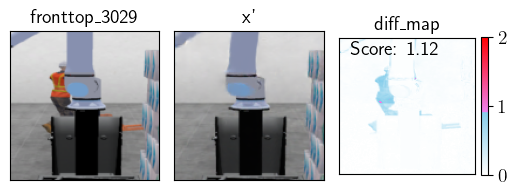

In [115]:
top_1_fname = top_1_fname.strip()   # e.g. 'fronttop_1196'

target_idx = None
for i, (img_path, img_lbl) in enumerate(dataset.imgs):
    fname = 'fronttop_' + img_path.split('/')[-1].split('.')[0].split('\\')[-1].split('_')[1]
    if fname == top_1_fname:
        target_idx = i
        break

print("target_idx:", target_idx)

verify_max_values(val_dataset,index=target_idx)

In [116]:
print('frame with highest score \t-->', top_1_fname)
print('highest score \t\t\t-->', top_1_as)

print('CSV FILE SAVED as \t\t-->', csv_filename_anomaly_scores_val)


frame with highest score 	--> fronttop_3029
highest score 			--> 1.1117264032363894
CSV FILE SAVED as 		--> e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/val_fronttop_RoboArm_anomaly_scores_3_1.0_0.99.csv


In [117]:
print('maximum\t:', get_threshold(df_val, selector='max'))
print('top 1%\t:',  get_threshold(df_val, selector='q', quantile=0.99))   # top 1%
print('top 5%\t:',  get_threshold(df_val, selector='q', quantile=0.95))   # top 5%
print('top 10%\t:', get_threshold(df_val, selector='q', quantile=0.90))   # top 10%


maximum	: 1.1117264032363894
top 1%	: 0.3939351892471314
top 5%	: 0.1326629282534122
top 10%	: 0.0977055794000625


## PLOT TIMELINE

In [118]:
df_train.head(3)

,file_name,anomaly_score,label
0,fronttop_0000,0.069866,0
1,fronttop_0001,0.070982,0
2,fronttop_0002,0.069543,0


In [119]:
df_train.anomaly_score.min(), df_train.anomaly_score.max()

df_train_n = df_train.sort_values('anomaly_score', ascending=False)
df_train_n.head(3)

,file_name,anomaly_score,label
2605,fronttop_3256,0.411752,0
4620,fronttop_5775,0.214997,0
4764,fronttop_5955,0.191118,0


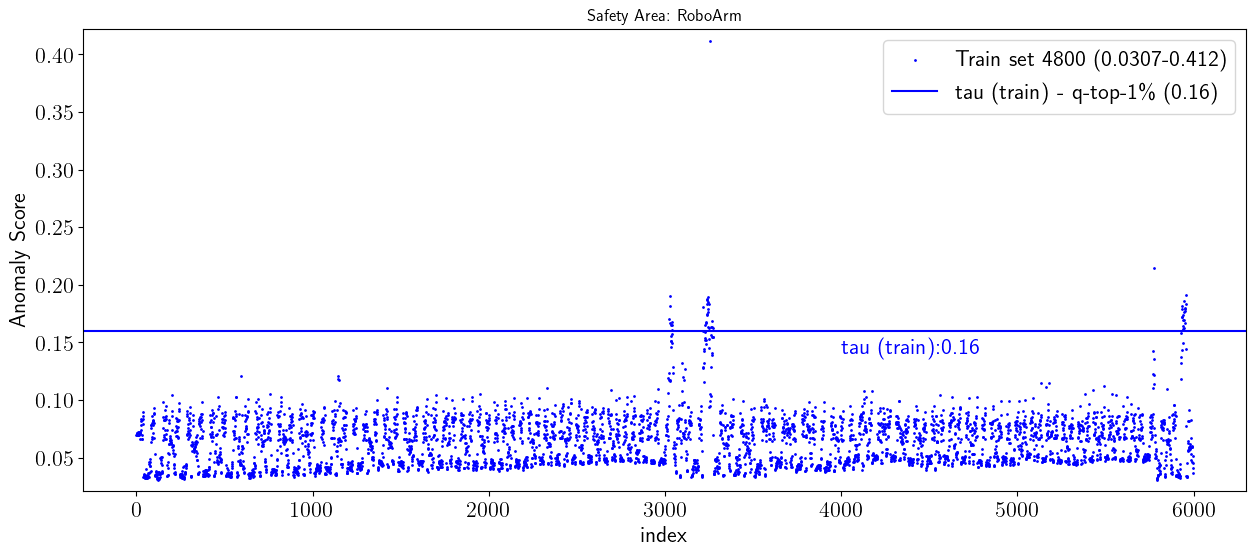

In [121]:
#--------------------------------------------------------------------------------------------------------------------
# selector='max'
selector, quantile,txt_lbl='q', 0.99, 'top-1\%'   # top 1%
# selector, quantile,txt_lbl='q', 0.95, 'top-5%'   # top 5%
# selector, quantile,txt_lbl='q', 0.90, 'top-10%'   # top 10%

thresh_train = get_threshold(df_train, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%
fontsize=16
x_point = 1000 if params.subgroup=='PLeft' else 4000
#--------------------------------------------------------------------------------------------------------------------
fns_train = [int(x.split('_')[-1]) for x in df_train.file_name]
plt.figure(figsize=(15, 6))
plt.scatter(fns_train, df_train.anomaly_score, color='blue', s=1,
            label=f'Train set {len(fns_train)} ({df_train.anomaly_score.min():0.3}-{df_train.anomaly_score.max():0.3})')
#--------------------------------------------------------------------------------------------------------------------
plt.ylim(df_train.anomaly_score.min() - 0.01, df_train.anomaly_score.max() + 0.01)  # ← clamp to data range
plt.text(x_point,thresh_train-0.02,f'tau (train):{thresh_train:0.3}', color='blue', fontsize=fontsize)
plt.axhline(thresh_train, color='blue', label=f'tau (train) - {selector}-{txt_lbl} ({thresh_train:0.3})')
plt.xlabel('index', fontsize=fontsize)
plt.ylabel('Anomaly Score', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.xticks(fontsize=fontsize); plt.yticks(fontsize=fontsize)
plt.title(f'Safety Area: {params.subgroup}')
plt.show()

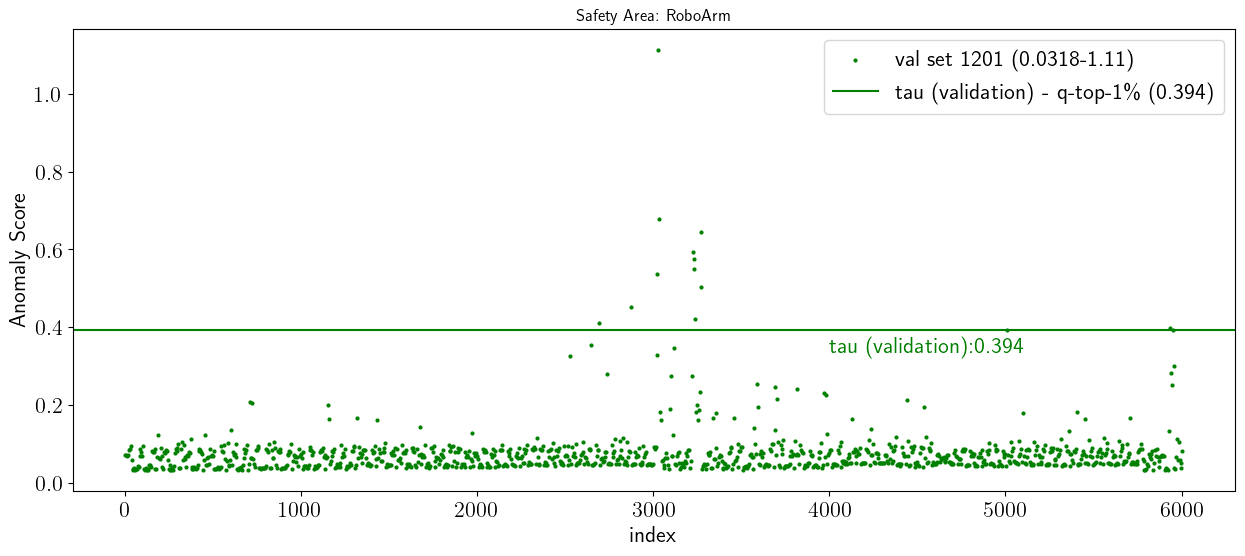

In [122]:
#-------------------------------------------------------------------
# selector,txt_lbl='max', 
# selector, quantile,txt_lbl='q', 1.00, 'top-0\%'   # Maximum
selector, quantile,txt_lbl='q', 0.99, 'top-1\%'   # top 1%
# selector, quantile,txt_lbl='q', 0.95, 'top-5%'   # top 5%
# selector, quantile,txt_lbl='q', 0.90, 'top-10%'   # top 10%
#-------------------------------------------------------------------
thresh_val = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%
#-------------------------------------------------------------------
x_point = 1000 if params.subgroup=='PLeft' else 4000
fontsize=16

fns_val = [int(x.split('_')[-1]) for x in df_val.file_name]
plt.figure(figsize=(15,6))
plt.scatter(fns_val, df_val.anomaly_score, s=4 , color='green', 
            label=f'val set {len(fns_val)} ({df_val.anomaly_score.min():0.3}-{df_val.anomaly_score.max():0.3})')
plt.axhline(thresh_val, color='green', label=f'tau (validation) - {selector}-{txt_lbl} ({thresh_val:0.3})')
plt.text(x_point,thresh_val-0.06,f'tau (validation):{thresh_val:0.3}', color='green', fontsize=fontsize)
#-------------------------------------------------------------------
plt.xlabel('index', fontsize=fontsize)
plt.ylabel('Anomaly Score', fontsize=fontsize)
plt.legend(fontsize=16)
plt.xticks(fontsize=fontsize); plt.yticks(fontsize=fontsize)
plt.title(f'Safety Area: {params.subgroup}')
plt.show()

In [123]:
# df_train.anomaly_score.min(), df_train.anomaly_score.max()

df_train_n = df_train.sort_values('anomaly_score', ascending=False)
df_train_n

,file_name,anomaly_score,label
2605,fronttop_3256,0.411752,0
4620,fronttop_5775,0.214997,0
4764,fronttop_5955,0.191118,0
2421,fronttop_3026,0.189918,0
2598,fronttop_3247,0.189289,0
...,...,...,...
99,fronttop_0123,0.031423,0
4633,fronttop_5791,0.031384,0
103,fronttop_0128,0.031329,0
4634,fronttop_5792,0.030929,0


In [124]:
selector, quantile,txt_lbl='q', 0.99, 'top-1\%'   # top 1%

def get_txt(quantile=0.99): return f'top-{int((1.00-quantile)*100)}\%'


get_txt(quantile=0.99)

'top-1\\%'

thresh_train    --> 0.16026295000000004
thresh_val      --> 0.3939351892471314


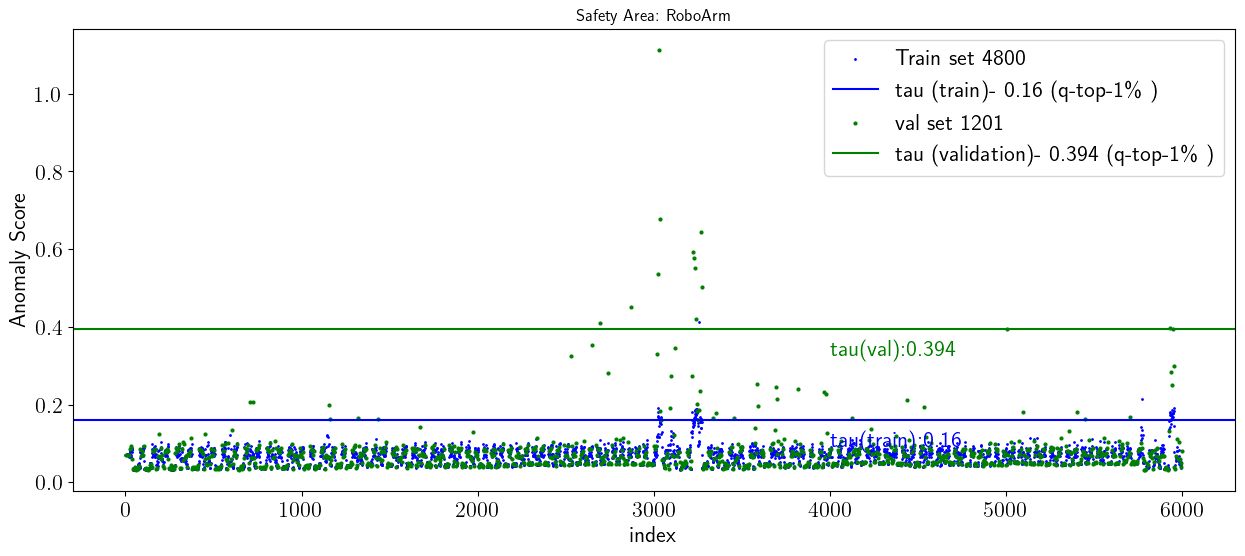

In [125]:
# quantile = 1.00
quantile = 0.99
# quantile = 0.95
# quantile = 0.90

txt_lbl = get_txt(quantile=quantile)

thresh_val = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%
thresh_train = get_threshold(df_train, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%

# thresh_train = df_train_n.anomaly_score.max()
# thresh_val = df_val.anomaly_score.max()

print(f'thresh_train    --> {thresh_train}')
print(f'thresh_val      --> {thresh_val}')

x_point = 1000 if params.subgroup=='PLeft' else 4000
#--------------------------------------------------------------------------------------------
plt.figure(figsize=(15, 6))
fns_train = [int(x.split('_')[-1]) for x in df_train_n.file_name]

thresh_val = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%

plt.scatter(fns_train, df_train_n.anomaly_score, color='blue', s=1,
            label=f'Train set {len(fns_train)}') # (a: {df_train_n.anomaly_score.min():0.3} - {thresh_train:0.3})
plt.text(x_point,thresh_train-0.07,f'tau(train):{thresh_train:0.3}', color='blue', fontsize=16)
plt.axhline(thresh_train, color='blue', label=f'tau (train)- {thresh_train:0.3} ({selector}-{get_txt(quantile=quantile)} )')
#-----------------------------------------------------------------------------------------------------------------------------
fns_val = [int(x.split('_')[-1]) for x in df_val.file_name]

plt.scatter(fns_val, df_val.anomaly_score,color='green', s=4,
            label=f'val set {len(fns_val)}') # - (a: {df_val.anomaly_score.min():0.3} - {thresh_val:0.3})
plt.axhline(thresh_val, color='green', label=f'tau (validation)- {thresh_val:0.3} ({selector}-{get_txt(quantile=quantile)} )')
plt.text(x_point,thresh_val-0.07,f'tau(val):{thresh_val:0.3}', color='green', fontsize=16)
#-----------------------------------------------------------------------------------------------------------------------------
# plt.scatter(10, 1000, color='red')    ← remove this
# plt.yticks([0, 0.5, 0.9, 1])        # ← remove 1000 from here too
#-----------------------------------------------------------------------------------------------------------------------------
plt.xlabel('index', fontsize=16)
plt.ylabel('Anomaly Score', fontsize=16)
plt.xticks(fontsize=fontsize); plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(f'Safety Area: {params.subgroup}')
plt.show()

In [126]:
# # selector,txt_lbl='max', 
# selector, quantile,txt_lbl='q', 0.99, 'top-1\%'   # top 1%
# # selector, quantile,txt_lbl='q', 0.95, 'top-5%'   # top 5%
# # selector, quantile,txt_lbl='q', 0.90, 'top-10%'   # top 10%
# #-------------------------------------------------------------------
# thresh_val = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%

# thresh_val

## GET MAXIMUM THRESHOLD VALUE FROM VALIDATION SET

In [127]:
import importlib

In [128]:
anomaly_type = 'unexpected_person'

paths.test_dir = os.path.join(paths.path_datasets, f'fronttop/test_processed/{anomaly_type}/{params.subgroup}')#, paths.test_dir
paths.test_dir


'D:/DS/VeleriaLab\\V6\\fronttop/test_processed/unexpected_person/RoboArm'

In [129]:
importlib.reload(utc)
test_loader_demo,test_dataset_demo = utc.get_test_loaders_from_processed_data_new(paths,
                                            params,
                                            subgroup = params.subgroup,
                                            data_type='test',
                                            sel_type='auto-mask', # auto-mask
                                            mask_image_name = mask_image_name,
                                            # keep_folders = keep_folders,#['normal','PRight'],
                                            batch_size=1,
                                            shuffle_data=False,
                                            num_workers=0, pin_memory=True)

print('test path \t', test_loader_demo.dataset.root)
print('total images \t', len(test_loader_demo.dataset))
print('batch_size \t',test_loader_demo.batch_size)

print('test dataset \t',test_loader_demo.dataset.classes)

print(test_dataset_demo[0][0].shape)

Using fronttop dataset
component_mask.shape (720, 1280)
data_dir 	 D:/DS/VeleriaLab\V6\fronttop/test_processed/unexpected_person/RoboArm
test path 	 D:/DS/VeleriaLab\V6\fronttop/test_processed/unexpected_person/RoboArm
total images 	 5864
batch_size 	 1
test dataset 	 ['normal', 'unexpected_person']
torch.Size([3, 128, 128])


In [130]:
print('test loader_demo.dataset.classes', test_loader_demo.dataset.classes)
print('test path \t', test_loader_demo.dataset.root)

test loader_demo.dataset.classes ['normal', 'unexpected_person']
test path 	 D:/DS/VeleriaLab\V6\fronttop/test_processed/unexpected_person/RoboArm


In [131]:
from pathlib import Path

# Pre-extract just once
files_test = [f"fronttop_{Path(p).stem.split('_')[1]}" for p, _ in tqdm(test_dataset_demo.imgs, desc="Extracting file names")]

print(len(files_test), files_test[:5])

Extracting file names:   0%|          | 0/5864 [00:00<?, ?it/s]

5864 ['fronttop_0000', 'fronttop_0001', 'fronttop_0002', 'fronttop_0003', 'fronttop_0004']


In [132]:
def get_sample(test_dataset,img_index=0,verbose = True):
    # real_images, labels,file = next(iter(test_loader_demo))
    # real_images, labels = next(iter(test_loader))
    print ('image index', test_dataset.imgs[img_index][0])
    if len(test_dataset[idx])==3:
        real_images, _,_ = test_dataset[idx]
    else:
        real_images, _ = test_dataset[idx]
    real_images = real_images.unsqueeze(0)
    real_images = real_images.to(device)
    if verbose:
        print('real_images', real_images.shape)
    z, _ = Enc(real_images)
    reconstructed_images = Dec(z)
    if verbose:
        print('reconstructed_images', reconstructed_images.shape)

    return real_images, reconstructed_images

In [133]:
len(anomaly_scores_fn),params.subgroup

(53, 'RoboArm')

In [134]:
import math
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

def compute_anomaly_summary_single(
    name,
    score_fn,
    test_loader_,
    good_classname,
    compute_scores,
    params,
    fixed_threshold,
    inspect_mode=False,
    inspect_level=1,
):
    """
    Compute all metrics and derived quantities for a SINGLE anomaly score method,
    using a FIXED threshold (no threshold search here).

    Behavior:
    - If both classes {0,1} exist in labels: compute everything (incl. ROC/AUC).
    - If only one class exists (e.g., no anomalies): still compute thresholded metrics
      and TN/TP stats, but AUC/ROC are set to NaN / empty (undefined).
    """
    # --- 1) Get raw scores + labels once ---
    scores, labels, _, _ = compute_scores(
        test_loader_, good_classname, score_fn, name=name
    )

    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    tau = float(fixed_threshold)

    # --- 2) Predictions & always-defined metrics ---
    preds = (scores >= tau).astype(int)

    accuracy  = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall    = recall_score(labels, preds, zero_division=0)
    f1        = f1_score(labels, preds, zero_division=0)

    # --- 3) ROC/AUC only if both classes exist in labels ---
    unique_labels = np.unique(labels)
    has_both_classes = (len(unique_labels) == 2) and set(unique_labels.tolist()) == {0, 1}

    if has_both_classes:
        auc = roc_auc_score(labels, scores)
        fpr, tpr, _ = roc_curve(labels, scores)
    else:
        # Undefined with a single class present
        auc = np.nan
        fpr = np.array([], dtype=float)
        tpr = np.array([], dtype=float)

    # --- 4) TN / TP subsets under this threshold ---
    true_negatives = [s for s, y in zip(scores, labels) if (y == 0 and s <  tau)]
    true_positives = [s for s, y in zip(scores, labels) if (y == 1 and s >= tau)]

    tnv = np.asarray(true_negatives, dtype=float)
    tpv = np.asarray(true_positives, dtype=float)

    tn_mean, tn_std = (tnv.mean(), tnv.std()) if len(tnv) > 0 else (np.nan, np.nan)
    tp_mean, tp_std = (tpv.mean(), tpv.std()) if len(tpv) > 0 else (np.nan, np.nan)

    # binormal distance (binormal AUC-style); meaningful only if both groups exist with some variance
    if (len(tnv) > 0 and len(tpv) > 0
        and not np.isnan(tn_std) and not np.isnan(tp_std)
        and (tn_std > 0 or tp_std > 0)):
        binormal_auc = abs(tn_mean - tp_mean) / math.sqrt(tn_std**2 + tp_std**2)
    else:
        binormal_auc = np.nan

    if inspect_mode and inspect_level >= 1:
        print(f"\n[compute_anomaly_summary_single] {name}")
        print(f"  threshold (tau) = {tau:.6f}")
        print(f"  labels present  = {unique_labels.tolist()}")
        print(f"  Acc={accuracy:.3f}, F1={f1:.3f}, "
              f"Prec={precision:.3f}, Rec={recall:.3f}, "
              f"AUC={'nan' if np.isnan(auc) else f'{auc:.3f}'}, "
              f"binAUC={'nan' if np.isnan(binormal_auc) else f'{binormal_auc:.3f}'}")

        if not has_both_classes:
            print("  [INFO] ROC/AUC skipped (only one class present in labels).")

    # --- 5) Pack everything in a reusable summary dict ---
    summary = {
        "name": name,
        "tau": tau,
        "scores": scores,
        "labels": labels,
        "preds": preds,
        "tn_scores": tnv,
        "tp_scores": tpv,
        "tn_mean": tn_mean,
        "tn_std": tn_std,
        "tp_mean": tp_mean,
        "tp_std": tp_std,
        "metrics": {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc": auc,
            "binormal_auc": binormal_auc,
        },
        "roc": {
            "fpr": fpr,
            "tpr": tpr,
        },
        "params": {
            "subgroup": params.subgroup,
            "epochs": params.epochs,
            "epochs_loaded": getattr(params, "epochs_loaded", None),
        },
        # optional flag (handy in plotting/logging)
        "has_both_classes": has_both_classes,
    }

    return summary


In [135]:
def compute_scores(data_loader, good_classname, score_fn, name=''):
    scores = []
    out_labels = []
    label_real = []
    files = []

    class_names = data_loader.dataset.classes

    for batch in tqdm(data_loader, desc=f'{name}'):
        if len(batch) == 3:
            real_images, labels, fns = batch
        else:
            real_images, labels = batch
            fns = [None] * len(labels)

        labels_np = labels.cpu().numpy()
        label_real_batch = [class_names[int(l)] for l in labels_np]

        out_labels_batch = [(cls != good_classname) for cls in label_real_batch]

        real_images = real_images.to(device)

        z_mean, z_logvar = Enc(real_images)
        z = z_mean
        reconstructed_images = Dec(z)

        batch_scores = score_fn(real_images, reconstructed_images)
        if isinstance(batch_scores, torch.Tensor):
            batch_scores = batch_scores.detach().cpu().numpy().tolist()

        scores.extend(batch_scores)
        out_labels.extend([int(x) for x in out_labels_batch])
        label_real.extend(label_real_batch)
        files.extend(fns)

    return scores, out_labels, files, label_real


## GET THRESHOLD FROM VALIDATION SET

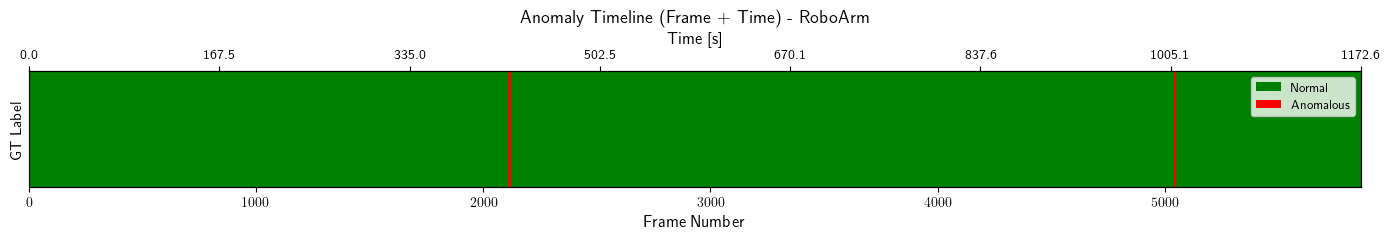

In [136]:
# gt, frame_idx, times = utc.plot_label_timeline_dual(test_loader_demo, fps=5)
# gt, frame_idx, times = utc.plot_label_timeline_dual(test_dataset_demo, fps=5)

# gt, frame_idx, times = utc.plot_label_timeline_dual_axis(test_loader_demo, fps=5)
# gt, frame_idx, times = utc.plot_label_timeline_dual_axis(test_dataset_demo, fps=5, title = f"Anomaly Timeline (Frame + Time) - {params.subgroup}")

In [137]:
thresh_val = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%
print(f'  tau: {thresh_val} (using {selector}-{quantile}) on validation set')

  tau: 0.3939351892471314 (using q-0.99) on validation set


In [138]:
best_anomaly_score_index,best_anom_score,*_ = get_index_used_for_calibration()
# offset=3,sigma=1.0,quan=0.99
# top_1_fname,top_1_as = df_val.loc[df_val.anomaly_score.idxmax()].file_name, df_val.loc[df_val.anomaly_score.idxmax()].anomaly_score

# top_1_fname,top_1_as = df_val.loc[df_val.anomaly_score.idxmax()].file_name, df_val.loc[df_val.anomaly_score.idxmax()].anomaly_score
# best_threshold = top_1_as


best_threshold = get_threshold(df_val, selector=selector, quantile=None if selector=='max' else quantile)  #top 1%

print(f'  tau: {best_threshold} (using {selector}-{quantile}) on validation set')

  tau: 0.3939351892471314 (using q-0.99) on validation set


In [139]:
TEST_THRESHOLD_ON_WINNER = True

if TEST_THRESHOLD_ON_WINNER:
    best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
    print(f'{"best_anom_score":<30} {best_anom_score}')
    print(f'{"best_anomaly_score_index":<30} {best_anomaly_score_index} ')
    print(f'{"best_threshold":<30} {best_threshold}' )


best_anom_score                OFF-o3-q0.99-s1.0
best_anomaly_score_index       51 
best_threshold                 0.3939351892471314


In [140]:
from sklearn.linear_model import LinearRegression
good_classname = train_loader.dataset.classes[0]
print(good_classname)
# params.subgroup = 'PRight'
allowed_cam_angle = [params.subgroup, good_classname]
allowed_cam_angle

normal


['RoboArm', 'normal']

In [141]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_anomaly_timeline_rich(
    summary,
    params,
    paths,
    save_dir="anomaly_plots_timeline",
    fps=5.0,
    figsize=(14, 6),
    fontsize_legend = 14,
    destroy_fig=False,
    debugg_ = False,
    title_suffix=""
):
    """
    Rich timeline-style visualization for a single anomaly score function.

    Top subplot:
      - line plot of anomaly score over time (seconds)
      - threshold line
      - markers for TN / TP / FP / FN
      - shaded regions where ground-truth labels are anomalous

    Bottom subplot:
      - ground-truth label strip (0 = normal, 1 = anomalous) over time

    Only uses precomputed values from `summary` (no recomputation from dataloader).
    """

    os.makedirs(save_dir, exist_ok=True)

    name    = summary["name"]
    scores  = np.asarray(summary["scores"])
    labels  = np.asarray(summary["labels"])
    tau     = float(summary["tau"])

    # If predictions are not stored, derive them from scores and threshold
    preds = np.asarray(summary.get("preds", scores >= tau)).astype(int)
    if debugg_:
        print('-'*100)
        print('preds - ', len(preds), preds, np.unique(preds, return_counts=True))
        print('scores - ', np.max(scores), ' tau -->', tau )
        print('-'*100)
    n = len(scores)
    frames = np.arange(n)
    times = frames / float(fps)  # x-axis in seconds

    # -------------------------
    #  Compute TP / TN / FP / FN masks
    # -------------------------
    is_pos = (labels == 1)
    is_neg = (labels == 0)

    is_pred_pos = (preds == 1)
    is_pred_neg = (preds == 0)

    mask_TP = is_pos & is_pred_pos
    mask_TN = is_neg & is_pred_neg
    mask_FP = is_neg & is_pred_pos
    mask_FN = is_pos & is_pred_neg

    # -------------------------
    #  Build figure
    # -------------------------
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True, figsize=figsize,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # =========================================================
    # 1) TOP AXIS: Score curve + threshold + TP/TN/FP/FN + shading
    # =========================================================

    # Score curve
    # ax_top.plot(
    #     times,
    #     scores,
    #     color="blue",
    #     linewidth=1.2,
    #     label="Anomaly score"
    # )

    # Threshold line
    ax_top.axhline(
        y=tau,
        color="gray",
        linestyle="--",
        linewidth=1.0,
        label=f"Threshold = {tau:.4f}"
    )

    # Shaded regions where GT is anomalous (label=1)
    # Find contiguous anomalous segments
    in_anom = False
    start_t = None
    for i in range(n):
        if labels[i] == 1 and not in_anom:
            in_anom = True
            start_t = times[i]
        if (labels[i] == 0 and in_anom) or (in_anom and i == n - 1):
            # End of anomalous region
            end_index = i if labels[i] == 0 else i
            end_t = times[end_index]
            ax_top.axvspan(
                start_t,
                end_t,
                color="red",
                alpha=0.08
            )
            in_anom = False

    # Scatter markers:
    #   TN: green dots
    #   TP: red dots
    #   FP: red crosses (predicted anomaly but GT normal)
    #   FN: green crosses (missed anomaly)
    ax_top.scatter(
        times[mask_TN],
        scores[mask_TN],
        s=18,
        color="green",
        alpha=0.7,
        label=f"TN (normal, correct) - {len(times[mask_TN])}"
    )
    ax_top.scatter(
        times[mask_TP],
        scores[mask_TP],
        s=22,
        color="red",
        alpha=0.7,
        label=f"TP (anomaly, correct) - {len(times[mask_TP])}"
    )
    ax_top.scatter(
        times[mask_FP],
        scores[mask_FP],
        s=50,
        color = 'blue',
        # facecolors="none",
        # edgecolors="red",
        linewidths=1.2,
        marker="x",
        label=f"FP (normal, flagged) - {len(times[mask_FP])}"
    )
    ax_top.scatter(
        times[mask_FN],
        scores[mask_FN],
        s=50,
        color = 'orange',
        # facecolors="none",
        # edgecolors="green",
        linewidths=1.2,
        marker="x",
        label=f"FN (anomaly, missed) - {len(times[mask_FN])}"
    )

    # Title: use available metrics if present
    acc   = summary.get("accuracy", None)
    prec  = summary.get("precision", None)
    rec   = summary.get("recall", None)
    f1    = summary.get("f1", None)
    auc   = summary.get("auc", None)
    bauc  = summary.get("binormal_auc", None)

    metric_str_parts = []
    if acc   is not None: metric_str_parts.append(f"Acc: {acc:.3f}")
    if prec  is not None: metric_str_parts.append(f"Prec: {prec:.3f}")
    if rec   is not None: metric_str_parts.append(f"Rec: {rec:.3f}")
    if f1    is not None: metric_str_parts.append(f"F1: {f1:.3f}")
    if auc   is not None: metric_str_parts.append(f"AUC: {auc:.3f}")
    if bauc  is not None: metric_str_parts.append(f"binAUC: {bauc:.3f}")
    metric_str = " | ".join(metric_str_parts)

    # title_main = (
    #     f"Timeline of anomaly scores – {name}\n"
    #     f"{params.subgroup}  |  epochs {getattr(params,'epochs_loaded','?')} ({params.epochs})"
    # )
    title_main = (
        f"Timeline of Anomaly Scores in {params.subgroup} – $\delta$({name})"
    )

    if metric_str:
        title_main += f"\n{metric_str}"
    if title_suffix:
        title_main += f"\n{title_suffix}"

    ax_top.set_title(title_main, fontsize=fontsize_legend)
    ax_top.set_ylabel("Anomaly score", fontsize=fontsize_legend)
    ax_top.grid(True, linestyle="--", alpha=0.4)
    ax_top.tick_params(axis="both", labelsize=fontsize_legend-4)

    best_loc = 'upper right' if params.subgroup=='PRight' else 'upper left'
    ax_top.legend(fontsize=fontsize_legend, loc=best_loc)

    # =========================================================
    # 2) BOTTOM AXIS: GT label strip over time
    # =========================================================

    # We show a colored "strip": green = normal, red = anomalous
    # Use imshow with a 1×N image
    label_img = labels[np.newaxis, :]  # shape (1, N)

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["green", "red"])

    ax_bottom.imshow(
        label_img,
        aspect="auto",
        cmap=cmap,
        extent=[times[0], times[-1] if n > 1 else times[0] + 1.0/fps, 0, 1]
    )

    ax_bottom.set_yticks([])
    ax_bottom.set_ylabel("GT label", fontsize=fontsize_legend)
    ax_bottom.set_xlabel("Time [s]", fontsize=fontsize_legend)

    # Legend for strip
    legend_elements = [
        Patch(facecolor="green", edgecolor="none", label="Normal (GT = 0)"),
        Patch(facecolor="red", edgecolor="none", label="Anomalous (GT = 1)")
    ]
    ax_bottom.legend(
        handles=legend_elements,
        loc=best_loc,
        fontsize=fontsize_legend
    )

    # Set limits and grid style
    ax_bottom.set_ylim(0, 1)
    ax_bottom.grid(False)
    ax_bottom.tick_params(axis="both", labelsize=fontsize_legend-4)
    # Shared layout
    plt.tight_layout()

    # Save
    out_path = os.path.join(save_dir,f"{name.replace(' ', '_')}_{params.subgroup}_timeline_rich.png")
    plt.savefig(os.path.join(save_dir,f"{name.replace(' ', '_')}_{params.subgroup}_timeline_rich.png"), bbox_inches="tight", dpi=200)
    plt.savefig(os.path.join(save_dir,f"{name.replace(' ', '_')}_{params.subgroup}_timeline_rich.pdf"), bbox_inches="tight", dpi=200)

    print(f"[plot_anomaly_timeline_rich] Saved figure to: {out_path}")

    if destroy_fig:
        plt.close(fig)
    
    plt.show()


In [ ]:
params.epochs_loaded = len(loss_history)

In [ ]:
strategy = 'train'

#-------------------------------------------------------------------
#-----------------------
# selector, quantile='q', 1.00   # MAX( top 0%)
selector, quantile='q', 0.99   # top 1%
# selector, quantile='q', 0.95   # top 5%
# selector, quantile='q', 0.90   #

best_threshold_train = get_threshold(df_train, selector=selector)

best_threshold = get_threshold(df_val, selector=selector, quantile = quantile)

print(strategy, best_threshold, selector)

0.3939351892471314 val q


In [ ]:

strategy = 'val'

#-------------------------------------------------------------------
#-----------------------
# selector, quantile='q', 1.00   # MAX( top 0%)
selector, quantile='q', 0.99   # top 1%
# selector, quantile='q', 0.95   # top 5%
# selector, quantile='q', 0.90   # top 10%
#-----------------------
#-------------------------------------------------------------------
thresh_val = get_threshold(df_val, selector=selector, quantile=quantile)  #top 1%
#-------------------------------------------------------------------

best_threshold = thresh_val

best_name, best_fn, _ = anomaly_scores_fn[best_anomaly_score_index]

print('-'*100)
print(f'AS \t--> {best_name} ')
print(f'using | q:{quantile:<8} | tau --> {thresh_val:<10.4}')
print('-'*100)


----------------------------------------------------------------------------------------------------
AS 	--> OFF-o3-q0.99-s1.0 
using | q:0.99     | tau --> 0.3939    
----------------------------------------------------------------------------------------------------


In [ ]:
if TEST_THRESHOLD_ON_WINNER:
    importlib.reload(utc)
    best_name, best_fn, _ = anomaly_scores_fn[best_anomaly_score_index]

    # Where to cache summary
    summary_json_path = utc.get_summary_json_path(f'{paths.path_codes_main}/test/{params.subgroup}_{strategy}_{selector}', params, best_name)
    import json
    if os.path.exists(summary_json_path):
        print(f"[INFO] Loading cached summary from JSON:\n  {summary_json_path}")
        with open(summary_json_path, "r") as f:
            json_summary = json.load(f)
        summary = utc.json_to_summary(json_summary)

        # (Optional) sanity print
        if "metrics" in summary:
            m = summary["metrics"]
            print(
                f"  Loaded metrics -> "
                f"Acc={m['accuracy']:.3f}, F1={m['f1']:.3f}, "
                f"Prec={m['precision']:.3f}, Rec={m['recall']:.3f}, "
                f"AUC={m['auc']:.3f}, binAUC={m['binormal_auc']:.3f}"
            )
    else:
        print(f"[INFO] No cached summary found. Computing it once and saving to:\n  {summary_json_path}")
        
        # 1) compute everything ONCE for the winner
        summary = compute_anomaly_summary_single(
            name=best_name,
            score_fn=best_fn,
            test_loader_=test_loader_demo,
            good_classname=good_classname,
            compute_scores=compute_scores,
            params=params,
            fixed_threshold=best_threshold,
            inspect_mode=True,
            inspect_level=1,
        )
        
        # 2) save JSON-serializable version
        json_summary = utc.summary_to_jsonable(summary)
        os.makedirs(os.path.dirname(summary_json_path), exist_ok=True)
        with open(summary_json_path, "w") as f:
            json.dump(json_summary, f, indent=2)
        print("[INFO] Summary saved.")

[INFO] No cached summary found. Computing it once and saving to:
  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/test/RoboArm_val_q\summary_RoboArm_OFF-o3-q0.99-s1.0.json


OFF-o3-q0.99-s1.0:   0%|          | 0/5864 [00:00<?, ?it/s]

In [150]:
print('VERIFYING SUMMARY ---')
print(f"{thresh_val} \n{summary['tau']} \n{best_threshold} \n{best_threshold== thresh_val==summary['tau']}")

if not best_threshold== thresh_val==summary['tau']:
    print('MISMATCH')
    summary['tau'] = thresh_val
# thresh_val

VERIFYING SUMMARY ---
0.24449078828096402 
0.24449078828096402 
0.24449078828096402 
True


[plot_anomaly_timeline_rich] Saved figure to: e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/PRight/timeline-PRight\OFF-o3-q0.99-s1.0_PRight_timeline_rich.png


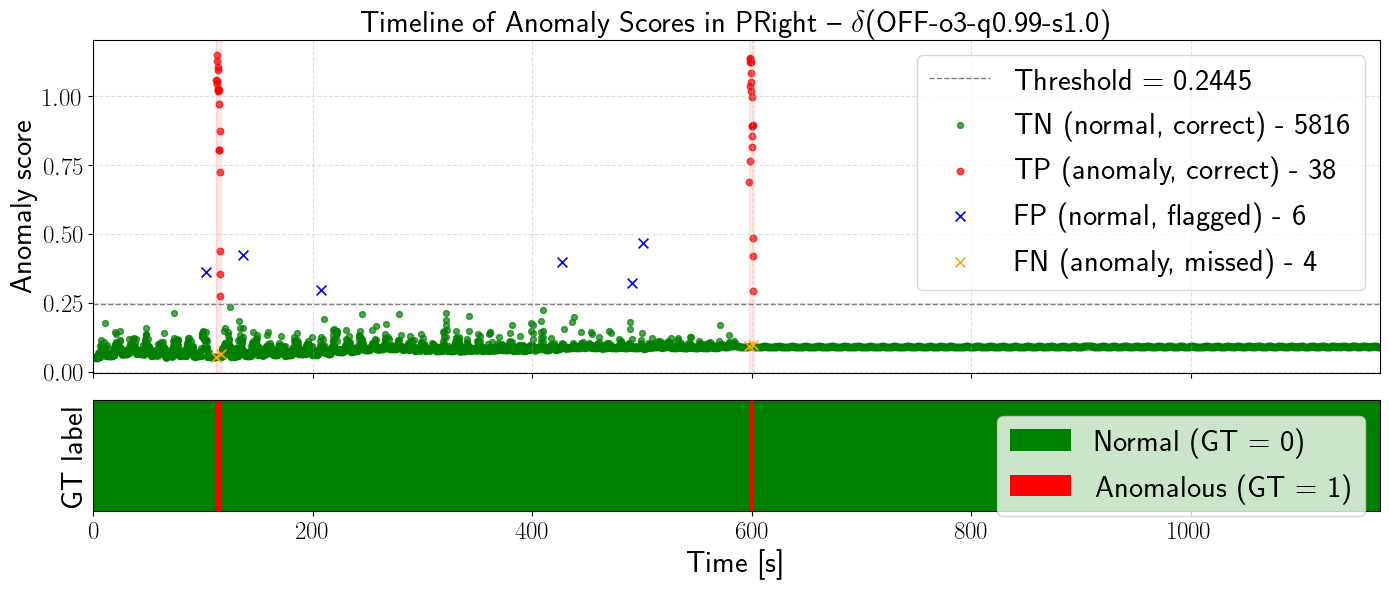

In [151]:
plot_anomaly_timeline_rich(
    summary,
    params=params,
    paths=paths,
    save_dir=f"{paths.path_codes_main}/{params.subgroup}/timeline-{params.subgroup}",
    fps=5.0,
    figsize=(14, 6),
    fontsize_legend = 22,
    destroy_fig=False,
)

### PLOT CONF MATRIX

In [154]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, cohen_kappa_score
)

def plot_confusion_matrix_from_json(
    json_path,
    figsize=(6, 5),
    fontsize=14,
    destroy_fig=False,
    normalize=False,
    show_colorbar=True,
):
    # -------------------------
    # Load json
    # -------------------------
    with open(json_path, "r") as f:
        summary = json.load(f)

    name   = summary.get("name", "model")
    labels = np.asarray(summary["labels"]).astype(int)
    preds  = np.asarray(summary["preds"]).astype(int)

    # -------------------------
    # Confusion matrix
    # -------------------------
    tn = np.sum((labels == 0) & (preds == 0))
    fp = np.sum((labels == 0) & (preds == 1))
    fn = np.sum((labels == 1) & (preds == 0))
    tp = np.sum((labels == 1) & (preds == 1))

    cm = np.array([[tn, fp], [fn, tp]], dtype=float)

    cm_show = cm.copy()
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_show = cm / row_sums

    # -------------------------
    # Metrics (manual + sklearn)
    # -------------------------
    total = len(labels)

    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    balanced_accuracy = (recall + specificity) / 2.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # sklearn metrics (more robust + paper-ready)
    precision_macro   = precision_score(labels, preds, average='macro', zero_division=0)
    recall_macro      = recall_score(labels, preds, average='macro', zero_division=0)
    f1_macro          = f1_score(labels, preds, average='macro', zero_division=0)

    precision_weighted = precision_score(labels, preds, average='weighted', zero_division=0)
    recall_weighted    = recall_score(labels, preds, average='weighted', zero_division=0)
    f1_weighted        = f1_score(labels, preds, average='weighted', zero_division=0)

    cohen_kappa = cohen_kappa_score(labels, preds)

    report = classification_report(
        labels, preds,
        target_names=["NORMAL (0)", "ANOMALOUS (1)"],
        zero_division=0
    )

    # -------------------------
    # Incorrect cases
    # -------------------------
    is_correct = labels == preds

    incorrect_indices = np.where(~is_correct)[0]
    fp_indices = np.where((labels == 0) & (preds == 1))[0]
    fn_indices = np.where((labels == 1) & (preds == 0))[0]

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_show, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Anomaly"], fontsize=fontsize+2)
    ax.set_yticklabels(["Normal", "Anomaly"], fontsize=fontsize+2)

    ax.set_xlabel('Predicted', fontsize=fontsize+4)
    ax.set_ylabel('Actual', fontsize=fontsize+4)
    ax.set_title("Confusion Matrix", fontsize=fontsize+2)

    # Adaptive text color
    threshold = cm_show.max() / 2.0

    for i in range(2):
        for j in range(2):
            val = cm_show[i, j]

            txt = f"{val:.3f}\n({int(cm[i, j])})" if normalize else f"{int(cm[i, j])}"
            color = "white" if val > threshold else "black"

            ax.text(j, i, txt, ha="center", va="center",
                    color=color, fontsize=fontsize+4, fontweight="bold")

    # Grid lines
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=fontsize)

    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Print results
    # -------------------------
    print(f"\nModel: {name}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

    print("\n=== Error Analysis ===")
    print(f"Incorrect cases     : {len(incorrect_indices)}")
    print(f"False Positives (FP): {len(fp_indices)}")
    print(f"False Negatives (FN): {len(fn_indices)}")
    
    print("=== Core Metrics ===")
    print(f"Accuracy           : {accuracy:.6f}")
    print(f"Precision          : {precision:.6f}")
    print(f"Recall (TPR)       : {recall:.6f}")
    print(f"Specificity (TNR)  : {specificity:.6f}")
    print(f"F1-score           : {f1:.6f}")
    print(f"Balanced Accuracy  : {balanced_accuracy:.6f}")
    print(f"FPR                : {fpr:.6f}")
    print(f"FNR                : {fnr:.6f}")
    print(f"Cohen Kappa        : {cohen_kappa:.6f}")

    print("\n=== Macro / Weighted ===")
    print(f"Precision (macro)  : {precision_macro:.6f}")
    print(f"Recall (macro)     : {recall_macro:.6f}")
    print(f"F1 (macro)         : {f1_macro:.6f}")
    print(f"Precision (weighted): {precision_weighted:.6f}")
    print(f"Recall (weighted)   : {recall_weighted:.6f}")
    print(f"F1 (weighted)       : {f1_weighted:.6f}")

    print("\n=== Classification Report ===")
    print(report)

    

    if destroy_fig:
        plt.close(fig)

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy,
        "fpr": fpr,
        "fnr": fnr,
        "cohen_kappa": cohen_kappa,
        "incorrect_indices": incorrect_indices,
        "fp_indices": fp_indices,
        "fn_indices": fn_indices
    }

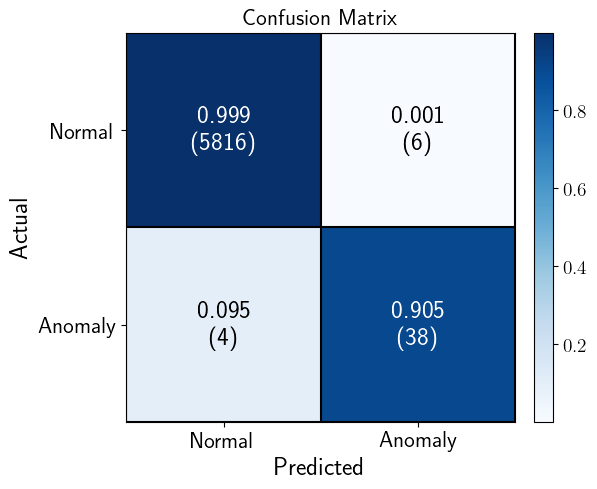


Model: OFF-o3-q0.99-s1.0
TN=5816, FP=6, FN=4, TP=38


=== Error Analysis ===
Incorrect cases     : 10
False Positives (FP): 6
False Negatives (FN): 4
=== Core Metrics ===
Accuracy           : 0.998295
Precision          : 0.863636
Recall (TPR)       : 0.904762
Specificity (TNR)  : 0.998969
F1-score           : 0.883721
Balanced Accuracy  : 0.951866
FPR                : 0.001031
FNR                : 0.095238
Cohen Kappa        : 0.882862

=== Macro / Weighted ===
Precision (macro)  : 0.931475
Recall (macro)     : 0.951866
F1 (macro)         : 0.941431
Precision (weighted): 0.998341
Recall (weighted)   : 0.998295
F1 (weighted)       : 0.998314

=== Classification Report ===
               precision    recall  f1-score   support

   NORMAL (0)       1.00      1.00      1.00      5822
ANOMALOUS (1)       0.86      0.90      0.88        42

     accuracy                           1.00      5864
    macro avg       0.93      0.95      0.94      5864
 weighted avg       1.00      1.00      1

In [155]:
# plot_confusion_matrix_from_json(summary_json_path, normalize=False, show_colorbar=False)
_ = plot_confusion_matrix_from_json(summary_json_path, normalize=True, show_colorbar=True)


### PLOT ROC

In [176]:
### NEW COLOR + PR SUPPORT
def plot_anomaly_summary_single(
    summary,
    params,
    paths,
    plot_types=("scores", "distributions", "roc", "pr"),
    save_dir="anomaly_plots_single",
    destroy_fig=False,
    title_suffix="",
    plot_title=False,
    plot_direction="horizontal",   # "horizontal" | "vertical"
    append_filename=None,
    fontsize_legend=10,
    legend_position="inside",      # "inside" | "bottom" | "bottom_shared"
    legend_compact=True,
    legend_compact_kwargs=None,
):
    """
    Plot anomaly-score behaviour for a SINGLE method.

    Supported plot_types:
    - "scores"
    - "distributions"
    - "roc"
    - "pr"

    Legend options:
    - "inside"        : legend inside each subplot
    - "bottom"        : legend below each subplot
    - "bottom_shared" : one shared legend below the entire figure
    """
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.lines import Line2D
    from sklearn.metrics import precision_recall_curve, average_precision_score

    os.makedirs(save_dir, exist_ok=True)

    # -------- legend style --------
    if legend_compact_kwargs is None:
        legend_compact_kwargs = {}

    compact_style_default = dict(
        handlelength=1.0,
        handletextpad=0.3,
        columnspacing=0.6,
        labelspacing=0.2,
        borderpad=0.2,
        markerscale=0.8,
    )
    legend_style = {}
    if legend_compact:
        legend_style.update(compact_style_default)
        legend_style.update(legend_compact_kwargs)

    name       = summary["name"]
    tau        = summary["tau"]
    scores     = np.asarray(summary["scores"])
    labels     = np.asarray(summary["labels"])
    preds      = np.asarray(summary["preds"])
    tnv        = np.asarray(summary["tn_scores"])
    tpv        = np.asarray(summary["tp_scores"])
    tn_mean    = summary["tn_mean"]
    tn_std     = summary["tn_std"]
    tp_mean    = summary["tp_mean"]
    tp_std     = summary["tp_std"]
    metrics    = summary["metrics"]
    roc_info   = summary.get("roc", {})

    accuracy     = metrics.get("accuracy", np.nan)
    precision_m  = metrics.get("precision", np.nan)
    recall_m     = metrics.get("recall", np.nan)
    f1           = metrics.get("f1", np.nan)
    auc          = metrics.get("auc", np.nan)
    binormal_auc = metrics.get("binormal_auc", np.nan)

    fpr = np.asarray(roc_info.get("fpr", []))
    tpr = np.asarray(roc_info.get("tpr", []))

    # ---------------------------
    # PR info: use precomputed if available, else compute
    # ---------------------------
    pr_info = summary.get("pr", {})
    if "precision" in pr_info and "recall" in pr_info:
        pr_precision = np.asarray(pr_info["precision"])
        pr_recall = np.asarray(pr_info["recall"])
        ap = float(pr_info.get("ap", pr_info.get("average_precision", np.nan)))
    else:
        pr_precision, pr_recall, _ = precision_recall_curve(labels, scores)
        ap = average_precision_score(labels, scores)

    # baseline for PR plot = positive prevalence
    positive_rate = float(np.mean(labels == 1)) if len(labels) > 0 else 0.0

    fontsize_ticks = max(6, fontsize_legend - 2)
    mrst = ['o', 'o', '+', '+']
    mrsz = [30, 30, 60, 60]
    
    # ---------------------------
    # Layout
    # ---------------------------
    # n_plots = len(plot_types)
    # is_horizontal = plot_direction.lower() in ["horizontal", "h", "row", "1xn"]
    

    # if is_horizontal:
    #     fig, ax_arr = plt.subplots(1, n_plots, figsize=(4 * n_plots, 3), squeeze=False)
    # else:
    #     fig, ax_arr = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), squeeze=False)

    # def get_ax(i):
    #     return ax_arr[0, i] if is_horizontal else ax_arr[i, 0]
    # ---------------------------
    # Layout (UPDATED for radar)
    # ---------------------------
    n_plots = len(plot_types)
    is_horizontal = plot_direction.lower() in ["horizontal", "h", "row", "1xn"]

    fig = plt.figure(figsize=(4 * n_plots, 3) if is_horizontal else (10, 3 * n_plots))

    axes = []
    for i, ptype in enumerate(plot_types):
        if is_horizontal:
            if ptype == "radar":
                ax = fig.add_subplot(1, n_plots, i + 1, projection="polar")
            else:
                ax = fig.add_subplot(1, n_plots, i + 1)
        else:
            if ptype == "radar":
                ax = fig.add_subplot(n_plots, 1, i + 1, projection="polar")
            else:
                ax = fig.add_subplot(n_plots, 1, i + 1)
        axes.append(ax)

    def get_ax(i):
        return axes[i]
    shared_handles, shared_labels = [], []

    # ---------------------------
    # (1) Scatter of anomaly scores
    # ---------------------------
    TN_color = 'green'
    TP_color = 'red'
    FP_color = 'blue'
    FN_color = 'orange'

    if "scores" in plot_types:
        ax1 = get_ax(plot_types.index("scores"))

        idx = np.arange(len(scores))
        mask_tn = (labels == 0) & (preds == 0)
        mask_fp = (labels == 0) & (preds == 1)
        mask_tp = (labels == 1) & (preds == 1)
        mask_fn = (labels == 1) & (preds == 0)

        ax1.scatter(idx[mask_tn], scores[mask_tn], label=f"TN ({mask_tn.sum()})", marker=mrst[0], s=mrsz[0], color=TN_color, alpha=0.7)
        ax1.scatter(idx[mask_tp], scores[mask_tp], label=f"TP ({mask_tp.sum()})", marker=mrst[1], s=mrsz[1], color=TP_color, alpha=0.7)
        ax1.scatter(idx[mask_fp], scores[mask_fp], label=f"FP ({mask_fp.sum()})", marker=mrst[2], s=mrsz[2], color=FP_color, alpha=0.7)
        ax1.scatter(idx[mask_fn], scores[mask_fn], label=f"FN ({mask_fn.sum()})", marker=mrst[3], s=mrsz[3], color=FN_color, alpha=0.7)

        ax1.axhline(y=tau, color="gray", linestyle="--", label=f"tau = {tau:.4f}")

        if plot_title:
            title_str = (
                f"$\\delta$({name}) - {params.subgroup}\n"
                f"Acc={accuracy:.2f} | F1={f1:.2f} | Prec={precision_m:.2f} | Rec={recall_m:.2f}"
            )
            if title_suffix:
                title_str += f"\n{title_suffix}"
            ax1.set_title(title_str, fontsize=fontsize_legend)

        ax1.set_xlabel("Frame Index", fontsize=fontsize_legend)
        ax1.set_ylabel("Anomaly Score", fontsize=fontsize_legend)
        ax1.tick_params(axis="both", labelsize=fontsize_ticks)
        ax1.grid(True)

        h, l = ax1.get_legend_handles_labels()
        shared_handles.extend(h)
        shared_labels.extend(l)

        if legend_position == "inside":
            ax1.legend(fontsize=fontsize_legend, **legend_style)
        elif legend_position == "bottom":
            ax1.legend(
                fontsize=fontsize_legend,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25),
                ncol=3,
                frameon=False,
                **legend_style
            )

    # ---------------------------
    # (2) KDE distributions of TN / TP + MEANS
    # ---------------------------
    if "distributions" in plot_types:
        ax2 = get_ax(plot_types.index("distributions"))

        df = pd.DataFrame({
            "value": np.concatenate([tnv, tpv]),
            "label": ["TN"] * len(tnv) + ["TP"] * len(tpv),
        })

        sns.kdeplot(
            data=df, x="value", hue="label",
            fill=True, common_norm=False,
            palette={"TN": "lightgreen", "TP": "pink"},
            ax=ax2
        )

        if not np.isnan(tn_mean):
            ax2.axvline(tn_mean, color=TN_color, linestyle="--", label=f"TN mean = {tn_mean:.2f}")
            if not np.isnan(tn_std):
                ax2.axvline(tn_mean - tn_std, color=TN_color, linestyle=":", linewidth=0.9, label="_nolegend_")
                ax2.axvline(tn_mean + tn_std, color=TN_color, linestyle=":", linewidth=0.9, label="_nolegend_")

        if not np.isnan(tp_mean):
            ax2.axvline(tp_mean, color=TP_color, linestyle="--", label=f"TP mean = {tp_mean:.2f}")
            if not np.isnan(tp_std):
                ax2.axvline(tp_mean - tp_std, color=TP_color, linestyle=":", linewidth=0.9, label="_nolegend_")
                ax2.axvline(tp_mean + tp_std, color=TP_color, linestyle=":", linewidth=0.9, label="_nolegend_")

        ax2.set_title("KDE of TN and TP", fontsize=fontsize_legend)
        ax2.set_xlabel("Anomaly Score", fontsize=fontsize_legend)
        ax2.set_ylabel("Density", fontsize=fontsize_legend)
        ax2.tick_params(axis="both", labelsize=fontsize_ticks)

        binormal_auc_safe = 0.0 if np.isnan(binormal_auc) else binormal_auc

        handles, labels_leg = ax2.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color="none", label=f"binAUC = {binormal_auc_safe:.4f}"))
        labels_leg.append(f"binAUC = {binormal_auc_safe:.4f}")

        if legend_position == "inside":
            ax2.legend(handles=handles, fontsize=fontsize_legend, **legend_style)
        elif legend_position == "bottom":
            ax2.legend(
                handles=handles,
                fontsize=fontsize_legend,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25),
                ncol=2,
                frameon=False,
                **legend_style
            )

        shared_handles.extend(handles)
        shared_labels.extend(labels_leg)

    # ---------------------------
    # (3) ROC curve
    # ---------------------------
    if "roc" in plot_types:
        ax3 = get_ax(plot_types.index("roc"))

        if len(fpr) > 0 and len(tpr) > 0:
            ax3.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color="blue")
        ax3.plot([0, 1], [0, 1], linestyle="--", color="gray")
        ax3.set_title("ROC Curve", fontsize=fontsize_legend)
        ax3.set_xlabel("False Positive Rate", fontsize=fontsize_legend)
        ax3.set_ylabel("True Positive Rate", fontsize=fontsize_legend)
        ax3.tick_params(axis="both", labelsize=fontsize_ticks)
        ax3.grid(True)

        h, l = ax3.get_legend_handles_labels()
        shared_handles.extend(h)
        shared_labels.extend(l)

        if legend_position == "inside":
            ax3.legend(fontsize=fontsize_legend, **legend_style)
        elif legend_position == "bottom":
            ax3.legend(
                fontsize=fontsize_legend,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25),
                ncol=2,
                frameon=False,
                **legend_style
            )

    # ---------------------------
    # (4) Precision-Recall curve
    # ---------------------------
    if "pr" in plot_types:
        ax4 = get_ax(plot_types.index("pr"))

        ax4.plot(pr_recall, pr_precision, label=f"AP = {ap:.2f}", color="purple")
        ax4.axhline(y=positive_rate, linestyle="--", color="gray", label=f"Baseline = {positive_rate:.2f}")
        ax4.set_title("Precision-Recall Curve", fontsize=fontsize_legend)
        ax4.set_xlabel("Recall", fontsize=fontsize_legend)
        ax4.set_ylabel("Precision", fontsize=fontsize_legend)
        ax4.tick_params(axis="both", labelsize=fontsize_ticks)
        ax4.grid(True)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1.02)

        h, l = ax4.get_legend_handles_labels()
        shared_handles.extend(h)
        shared_labels.extend(l)

        if legend_position == "inside":
            ax4.legend(fontsize=fontsize_legend, **legend_style)
        elif legend_position == "bottom":
            ax4.legend(
                fontsize=fontsize_legend,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25),
                ncol=2,
                frameon=False,
                **legend_style
            )


    # ---------------------------
    # (5) Radar Chart (Performance)
    # ---------------------------
    if "radar" in plot_types:
        ax5 = get_ax(plot_types.index("radar"))

        # Select meaningful metrics (avoid redundancy)
        radar_metrics = {
            "Accuracy": accuracy,
            "Precision": precision_m,
            "Recall": recall_m,
            "F1": f1,
            "AUC": auc,
        }

        # Convert to percentage
        categories = list(radar_metrics.keys())
        values = [v * 100 for v in radar_metrics.values()]

        # Close loop
        values += values[:1]
        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        angles += angles[:1]

        # Clear axis and make polar
        ax5.remove()
        ax5 = plt.subplot(
            1, len(plot_types), plot_types.index("radar") + 1,
            projection="polar"
        )

        ax5.plot(angles, values, 'o-', linewidth=2, color='#e74c3c')
        ax5.fill(angles, values, alpha=0.25, color='#e74c3c')

        ax5.set_xticks(angles[:-1])
        ax5.set_xticklabels(categories, fontsize=fontsize_ticks)

        ax5.set_ylim(0, 100)
        ax5.set_title("Performance Radar", fontsize=fontsize_legend)

        ax5.grid(True)

    # ---------------------------
    # Shared legend (optional)
    # ---------------------------
    if legend_position == "bottom_shared" and shared_handles:
        # remove duplicates while preserving order
        seen = set()
        uniq_handles, uniq_labels = [], []
        for h, l in zip(shared_handles, shared_labels):
            if l not in seen and l != "_nolegend_":
                uniq_handles.append(h)
                uniq_labels.append(l)
                seen.add(l)

        fig.legend(
            uniq_handles,
            uniq_labels,
            loc="lower center",
            ncol=min(6, len(uniq_handles)),
            fontsize=fontsize_legend,
            frameon=False,
            **legend_style
        )
        plt.subplots_adjust(bottom=0.25)

    plt.tight_layout()

    out_base = f"BEST_{params.subgroup}_{name.replace(' ', '_')}_plot"
    if append_filename:
        out_base += append_filename

    out_png = os.path.join(save_dir, out_base + ".png")
    out_pdf = os.path.join(save_dir, out_base + ".pdf")

    plt.savefig(out_png, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")

    print(f"[plot_anomaly_summary_single] Saved plot to: {out_png}")

    if destroy_fig:
        plt.close(fig)

    plt.show()

[plot_anomaly_summary_single] Saved plot to: e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/THESIS/PRight/plots_anomaly_results-PRight_SCORES_KDE\BEST_PRight_OFF-o3-q0.99-s1.0_plot.png


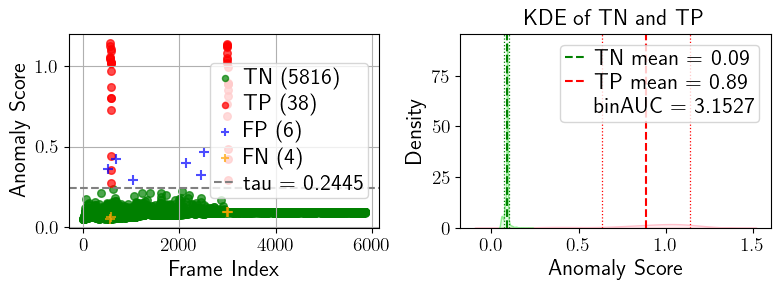

In [165]:
# Second variant: only ROC (for a clean ROC figure for thesis)
plot_anomaly_summary_single(
    summary,
    params=params,
    paths=paths,
    plot_types=("scores", "distributions"),
    save_dir=f"{paths.path_codes_main}/THESIS/{params.subgroup}/plots_anomaly_results-{params.subgroup}_SCORES_KDE",
    destroy_fig=False,
    title_suffix="(ROC only)",
    fontsize_legend = 16,
    )

[plot_anomaly_summary_single] Saved plot to: e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/THESIS/PRight/plots_anomaly_results-PRight_ROC\BEST_PRight_OFF-o3-q0.99-s1.0_plot.png


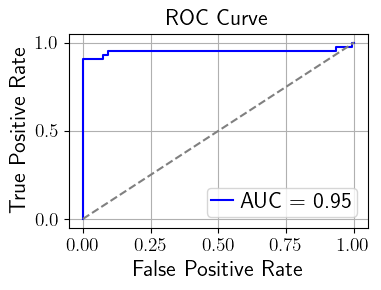

In [171]:
# Second variant: only ROC (for a clean ROC figure for thesis)
plot_anomaly_summary_single(
    summary,
    params=params,
    paths=paths,
    plot_types=("roc",),
    save_dir=f"{paths.path_codes_main}/THESIS/{params.subgroup}/plots_anomaly_results-{params.subgroup}_ROC",
    destroy_fig=False,
    title_suffix="(ROC only)",
    fontsize_legend = 16,
    )

[plot_anomaly_summary_single] Saved plot to: e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/THESIS/PRight/plots_anomaly_results-PRight_PR\BEST_PRight_OFF-o3-q0.99-s1.0_plot.png


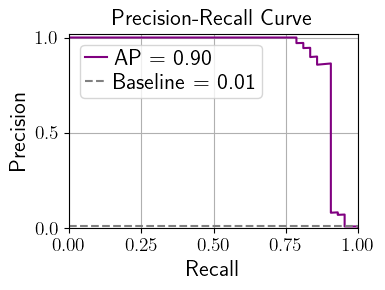

In [172]:
# Second variant: only ROC (for a clean ROC figure for thesis)
plot_anomaly_summary_single(
    summary,
    params=params,
    paths=paths,
    plot_types=("pr",),
    save_dir=f"{paths.path_codes_main}/THESIS/{params.subgroup}/plots_anomaly_results-{params.subgroup}_PR",
    destroy_fig=False,
    title_suffix="(ROC only)",
    fontsize_legend = 16,
    )

[plot_anomaly_summary_single] Saved plot to: e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/THESIS/PRight/plots_anomaly_results-PRight_PR\BEST_PRight_OFF-o3-q0.99-s1.0_plot.png


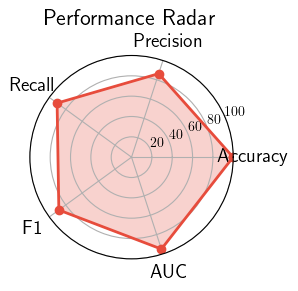

In [177]:
# Second variant: only ROC (for a clean ROC figure for thesis)
plot_anomaly_summary_single(
    summary,
    params=params,
    paths=paths,
    plot_types=("radar",),
    save_dir=f"{paths.path_codes_main}/THESIS/{params.subgroup}/plots_anomaly_results-{params.subgroup}_PR",
    destroy_fig=False,
    title_suffix="(ROC only)",
    fontsize_legend = 16,
    )